In [264]:
# imports
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.multitest import fdrcorrection, multipletests
from scipy import stats
from scipy.stats import levene, norm
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter
import matplotlib
import seaborn as sns
from matplotlib import cm, colors
from matplotlib.colors import to_rgb
import colorsys
import itertools
from scipy.spatial import distance

plt.rcParams['figure.dpi'] = 900
colors = plt.colormaps["Dark2"].colors
# set Arial as default font
plt.rcParams['font.family'] = 'Arial'
from tqdm import tqdm

# silence warnings because the NN has a lot of them
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from optuna import create_study
from optuna.trial import Trial
from tensorflow.keras import backend as K
import random

# for saving model params
import pickle

# for feature importance
import shap
from sklearn.metrics import mean_squared_error
import copy
import ast

# Read Model Outputs

All of these .pkl files are generated by `models.ipynb`.

In [ ]:
try:
	df_condition_level_data = pd.read_csv('../outputs/condition_level_group_advantage_with_ivs.csv') # mark's version of the cleaning

	# read the models and results from the previous save

	# main models
	with open('../outputs/models.pkl', 'rb') as f:
		MODELS = pickle.load(f)
	with open('../outputs/model_r2_results.pkl', 'rb') as f:
		MODEL_R2_RESULTS = pickle.load(f)
	with open('../outputs/model_rmse_results.pkl', 'rb') as f:
		MODEL_RMSE_RESULTS = pickle.load(f)
	
	# train/test data
	with open('../outputs/train_test_data.pkl', 'rb') as f:
		TRAIN_TEST_DATA = pickle.load(f)

	# noise robustness models and results
	with open('../outputs/enet_noise_robustness.pkl', 'rb') as f:
		ENETS_NOISE_ROBUSTNESS = pickle.load(f)
	with open('../outputs/enet_noise_robustness_r2_results.pkl', 'rb') as f:
		ENETS_NOISE_ROBUSTNESS_R2_RESULTS = pickle.load(f)
	with open('../outputs/enet_noise_robustness_rmse_results.pkl', 'rb') as f:
		ENETS_NOISE_ROBUSTNESS_RMSE_RESULTS = pickle.load(f)

	# IV lists
	with open('../outputs/iv_lists.pkl', 'rb') as f:
		IV_LISTS = pickle.load(f)
	
	basic_IVs = IV_LISTS['basic_IVs']
	mcgrath_continuous = IV_LISTS['mcgrath_continuous']
	steiner_continuous = IV_LISTS['steiner_continuous']
	laughlin_continuous = IV_LISTS['laughlin_continuous']
	categorical_IVs = IV_LISTS['categorical_IVs']

	print("Model files loaded successfully.")

except FileNotFoundError:
	print("Model files not found. Please run models.ipynb first to generate the outputs.")

Model files loaded successfully.


In [266]:
df_condition_level_data[df_condition_level_data['task']=='Writing Story']

,task,playerCount,strong,weak,Low,Medium,High,Conceptual-Behavioral,Type 1 (Planning),Type 2 (Generate),...,Time Solvability,Type 3 and Type 4 (Objective Correctness),Conflicting Tradeoffs,Solution Scheme Outcome Uncertainty,Eureka Question,Intellectual-Manipulative,Intellective-Judgmental,Creativity Input,Type 6 (Mixed-Motive),wave
114,Writing Story,3,0.923359,1.106073,1,0,0,0.0,0.125,0.4,...,0.291667,0.12,0.2,0.363636,0.0,0.088,0.096,0.916,0,1
115,Writing Story,6,0.918376,1.138170,1,0,0,0.0,0.125,0.4,...,0.291667,0.12,0.2,0.363636,0.0,0.088,0.096,0.916,0,1
116,Writing Story,3,0.900500,1.042608,0,1,0,0.0,0.125,0.4,...,0.291667,0.12,0.2,0.363636,0.0,0.088,0.096,0.916,0,1
117,Writing Story,6,0.958114,1.119171,0,1,0,0.0,0.125,0.4,...,0.291667,0.12,0.2,0.363636,0.0,0.088,0.096,0.916,0,1
118,Writing Story,3,0.954016,1.023305,0,0,1,0.0,0.125,0.4,...,0.291667,0.12,0.2,0.363636,0.0,0.088,0.096,0.916,0,1
119,Writing Story,6,0.946929,1.021956,0,0,1,0.0,0.125,0.4,...,0.291667,0.12,0.2,0.363636,0.0,0.088,0.096,0.916,0,1


# Model-Related Helper Functions

Duplicated from models.ipynb, these helper functions help us run and evaluate the models live as we plot them.

In [ ]:
def custom_r2(y_pred, y_actual, wave_a_data, wave_b_data, dv_type):
	# Compute R^2 on the test set, using the training set as a baseline
	naive_prediction_errs = []
	for i, row in wave_b_data.iterrows():
		
		# get all instances of groups of the same size performing 
		# all the tasks in the training set at the same comatplotlibexity level.
		playerCount = row["playerCount"]
		wave_a_subset = wave_a_data[(wave_a_data["playerCount"] == playerCount) & 
									(wave_a_data["Low"] == row["Low"]) & 
									(wave_a_data["Medium"] == row["Medium"]) &
									(wave_a_data["High"] == row["High"])]
		y_training = np.mean(wave_a_subset[dv_type])
		# predict the value of the DV (in wave_b) using the mean of the training data (from wave_a)
		y_actual_i = row[dv_type]
		fold_err = (y_actual_i - y_training)**2
		naive_prediction_errs.append(fold_err)

	r2 = 1 - np.sum((y_pred - y_actual)**2) / np.sum(naive_prediction_errs)
	
	return r2

In [ ]:
def add_interactions(X):
	poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
	return poly.fit_transform(X)

def get_rmse(y_true, y_pred):
	"""
	Calculate RMSE between true and predicted values.
	"""
	return np.sqrt(np.mean((y_true - y_pred) ** 2))

# function for getting RMSE from a trained model (OLS)
def get_rmse_ols(model_ols, X_test, y_true, ivs):
	X_test_ols = sm.add_constant(X_test[ivs].copy(), has_constant='add')
	y_pred_ols = model_ols.predict(X_test_ols)
	rmse_ols = get_rmse(y_true, y_pred_ols)

	return rmse_ols

def get_rmse_for_enet(model_enet, X_test, y_true, ivs):
	X_test_enet = add_interactions(X_test[ivs].copy())
	y_pred_enet = model_enet.predict(X_test_enet)
	rmse_enet = get_rmse(y_true, y_pred_enet)

	return rmse_enet

def get_rmse_for_nn_keras(model_nn, X_test, y_true, ivs):
	X = np.asarray(X_test[ivs], dtype=np.float32)
	y_true = np.asarray(y_true, dtype=np.float32).ravel()
	y_pred = model_nn.predict(X, verbose=0).ravel()
	return float(np.sqrt(np.mean((y_true - y_pred)**2)))

In [ ]:
def set_random_seeds(seed_value=19104):
	random.seed(seed_value)
	np.random.seed(seed_value)
	tf.random.set_seed(seed_value)

# Task Space / Group Advantage Figures

### Plotting Preprocessing

First, we need to take the results dictionaries and wrangle them so that we can plot them better.

In [ ]:
def create_plotting_dataframe(results_dict, train_test_data, metric_type):

	# metric types
	assert metric_type in ["R^2", "RMSE"], "metric_type must be either 'R^2' or 'RMSE'"

	plot_rows = []
	for iv, model_dict in results_dict.items():
		for model, wave_dict in model_dict.items():
			for wave, dv_dict in wave_dict.items():
				n_train = train_test_data[wave]["train"].shape[0]
				for dv_type, r2_val in dv_dict.items():
					plot_rows.append({
						"IV": iv,
						"Model": model,
						"Wave": wave,
						"n_train": n_train,
						"DV_Type": dv_type,
						metric_type: r2_val,
						"IV-Model": f"{iv}-{model}"
					})
	return pd.DataFrame(plot_rows)


df_plot_r2 = create_plotting_dataframe(MODEL_R2_RESULTS, TRAIN_TEST_DATA, "R^2")
df_plot_rmse = create_plotting_dataframe(MODEL_RMSE_RESULTS, TRAIN_TEST_DATA, "RMSE")

### Plotting Globals

Some general settings for colors to match the different models/types.

In [ ]:
# Map wave names to pretty x-axis labels
wave_pretty = {
	"Wave 1": "10",
	"Wave 2": "15"
}

# set up df_plot versions
df_plot_r2["Wave_Label"] = df_plot_r2["Wave"].map(wave_pretty)
df_plot_rmse["Wave_Label"] = df_plot_rmse["Wave"].map(wave_pretty)

# remove NN for now
if "NN" in df_plot_r2["Model"].unique() or "NN" in df_plot_rmse["Model"].unique():
	df_plot_r2 = df_plot_r2[df_plot_r2["Model"] != "NN"]
	df_plot_rmse = df_plot_rmse[df_plot_rmse["Model"] != "NN"]

# For ordering on x-axis
cat_order = [
	"10",
	"15"
]

# Hue color logic
base_palette = {
	"Task Space": "#1f77b4",   # blue family
	"McGrath Categorical": "#ff7f0e",  # orange family
	"McGrath Subspace": "#2ca02c",  # green family
	"Steiner Subspace": "#d62728",  # red family
	"Laughlin Subspace": "#9467bd"  # purple family
}

marker_dict = {
	"Task Space-OLS":"o","Task Space-E-Net":"s", "Task Space-NN":"^",
	"McGrath Categorical-OLS":"^","McGrath Categorical-E-Net":"v", "McGrath Categorical-NN":"<",
	"McGrath Subspace-OLS":"P","McGrath Subspace-E-Net":"X", "McGrath Subspace-NN":"*",
	"Steiner Subspace-OLS":"D", "Steiner Subspace-E-Net":"*",
	"Laughlin Subspace-OLS":"h", "Laughlin Subspace-E-Net":">"
}

shade_dict = {
	"OLS": 1.55,
	"E-Net": 1.00,
	"NN": 0.75
}

def get_color(iv, model):
	base = base_palette[iv]
	r, g, b = to_rgb(base)
	h, l, s = colorsys.rgb_to_hls(r, g, b)
	l_new = min(1.0, max(0, l * shade_dict[model]))
	r2, g2, b2 = colorsys.hls_to_rgb(h, l_new, s)
	return (r2, g2, b2)

For SHAP/Permutation analysis, we need to group strongly correlated columns together because this prevents another "copy" of the same dimension from existing in the model, unpermuted.

In [ ]:
# Define Task Space Groups
pretty_feature_cluster_names = {
	"['Type 2 (Generate)', 'Creativity Input']": "Creative",
	"['Type 3 and Type 4 (Objective Correctness)', 'Decision Verifiability', 'Shared Knowledge', 'Within-System Solution', 'Answer Recognizability', 'Time Solvability', 'Intellective-Judgmental']": "Demonstrably Correct Answer",
	"['Conceptual-Behavioral', 'Intellectual-Manipulative']": "Physical",
	"Type 1 (Planning)": "Type 1 (Planning)",
	"Type 5 (Cognitive Conflict)": "Type 5 (Cognitive Conflict)",
	"Type 6 (Mixed-Motive)": "Type 6 (Mixed-Motive)",
	"Type 7 (Battle)": "Type 7 (Battle)",
	"Type 8 (Performance)": "Type 8 (Performance)",
	"Divisible-Unitary": "Divisible-Unitary",
	"Maximizing": "Maximizing",
	"Optimizing": "Optimizing",
	"Outcome Multiplicity": "Outcome Multiplicity",
	"Solution Scheme Multiplicity": "Solution Scheme Multiplicity",
	"Conflicting Tradeoffs": "Conflicting Tradeoffs",
	"Solution Scheme Outcome Uncertainty": "Solution Scheme Outcome Uncertainty",
	"Eureka Question": "Eureka Question"
}

Show that the clusters are correlated:

In [273]:
df_condition_level_data[['Type 2 (Generate)', 'Creativity Input']].corr()

,Type 2 (Generate),Creativity Input
Type 2 (Generate),1.000000,0.829328
Creativity Input,0.829328,1.000000


In [274]:
df_condition_level_data[['Type 3 and Type 4 (Objective Correctness)', 'Decision Verifiability', 'Shared Knowledge', 'Within-System Solution', 'Answer Recognizability', 'Time Solvability', 'Intellective-Judgmental']].corr()

,Type 3 and Type 4 (Objective Correctness),Decision Verifiability,Shared Knowledge,Within-System Solution,Answer Recognizability,Time Solvability,Intellective-Judgmental
Type 3 and Type 4 (Objective Correctness),1.000000,0.967066,0.928585,0.654567,0.959369,0.975959,0.982612
Decision Verifiability,0.967066,1.000000,0.908816,0.682047,0.972943,0.973843,0.945500
Shared Knowledge,0.928585,0.908816,1.000000,0.611842,0.915565,0.933360,0.961674
Within-System Solution,0.654567,0.682047,0.611842,1.000000,0.721279,0.698743,0.598344
Answer Recognizability,0.959369,0.972943,0.915565,0.721279,1.000000,0.962793,0.946780
Time Solvability,0.975959,0.973843,0.933360,0.698743,0.962793,1.000000,0.959235
Intellective-Judgmental,0.982612,0.945500,0.961674,0.598344,0.946780,0.959235,1.000000


In [275]:
df_condition_level_data[['Conceptual-Behavioral', 'Intellectual-Manipulative']].corr()

,Conceptual-Behavioral,Intellectual-Manipulative
Conceptual-Behavioral,1.000000,0.974784
Intellectual-Manipulative,0.974784,1.000000


# Main Model Barplot

In [ ]:
def plot_group_advantage_rmse_with_r2(
	MODELS, wave, DATA, custom_r2, ivs_selected,
	models_to_plot=None,
	star_thresholds=(0.05, 0.01, 0.001),
	ivs_to_compare=None,
	NUM_BOOTSTRAP_SAMPLES=1000,
	rmse_fn_map = {"OLS": get_rmse_ols, "E-Net": get_rmse_for_enet, "NN": get_rmse_for_nn_keras} 
):
	
	# Default RMSE functions if none provided
	def _default_rmse_fn(model, X_test, y_true, ivs):
		X_in = X_test[ivs]
		y_pred = model.predict(X_in) if hasattr(model, "predict") else model(X_in)
		y_pred = np.asarray(y_pred).ravel()
		y_true = np.asarray(y_true).ravel()
		return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

	if rmse_fn_map is None:
		rmse_fn_map = {}
	
	# Helper to fetch per-model RMSE function
	def _get_rmse_fn(model_name):
		return rmse_fn_map.get(model_name, _default_rmse_fn)

	fallback_color = "#888"
	dvs = ["strong", "weak"]
	rng = np.random.default_rng(seed=19104)

	if models_to_plot is None:
		models = ["OLS", "E-Net"]
	else:
		models = [m for m in models_to_plot if m in ["OLS", "E-Net", "NN"]]

	def get_ivs_from_label(iv_label):
		if iv_label == "Task Space":
			return basic_IVs
		if iv_label == "McGrath Categorical":
			return categorical_IVs
		if iv_label == "McGrath Subspace":
			return mcgrath_continuous
		if iv_label == "Steiner Subspace":
			return steiner_continuous
		if iv_label == "Laughlin Subspace":
			return laughlin_continuous
		raise ValueError(f"Unknown IV type: {iv_label}")

	all_ivs = sorted(set(list(ivs_selected) + [iv for pair in ivs_to_compare for iv in pair]))

	boot_indices = {}
	for dv in dvs:
		n = len(DATA[wave]["test"])
		# this gets datapoints from the test wave with replacement
		boot_indices[dv] = [rng.integers(0, n, size=n) for _ in range(NUM_BOOTSTRAP_SAMPLES)]

	boot_rmse_map = {}
	point_rmse_map = {}
	r2_map = {}
	baseline_map = {}

	for iv in all_ivs:
		ivs_cols = get_ivs_from_label(iv)
		for model in models:
			for dv in dvs:
				try:
					mdl = MODELS[iv][model][wave][dv]
				except Exception:
					continue

				Xtest = DATA[wave]["test"]
				Xtrain = DATA[wave]["train"]
				y = Xtest[dv].values
				ytr = Xtrain[dv].mean()

				# get the predictions from all the different model types
				try:
					if model == "OLS":
						X_for_pred = sm.add_constant(Xtest[ivs_cols], has_constant="add")
					elif model == "E-Net":
						X_for_pred = add_interactions(Xtest[ivs_cols])
					elif model == "NN":
						X_for_pred = Xtest[ivs_cols]
					else:
						X_for_pred = Xtest[ivs_cols]
					yhat = mdl.predict(X_for_pred) if hasattr(mdl, "predict") else mdl(X_for_pred)
					yhat = np.asarray(yhat).ravel()
				except Exception:
					continue

				# Point estimate of the RMSE via the provided function (there are different functions for different models)
				rmse_fn = _get_rmse_fn(model)
				point_rmse = rmse_fn(mdl, Xtest, y, ivs_cols)
				point_rmse_map[(iv, model, dv)] = point_rmse
				r2_map[(iv, model, dv)] = custom_r2(yhat, y, DATA[wave]["train"], DATA[wave]["test"], dv)
				baseline_map[(iv, model, dv)] = float(np.sqrt(np.mean((ytr - y) ** 2)))

				# Bootstrapped RMSE via the provided function
				boot_vals = [rmse_fn(mdl, Xtest.iloc[idx], y[idx], ivs_cols) for idx in boot_indices[dv]]
				boot_rmse_map[(iv, model, dv)] = np.asarray(boot_vals, dtype=float)

	results = []
	for iv in ivs_selected:
		for model in models:
			for dv in dvs:
				key = (iv, model, dv)
				if key not in boot_rmse_map:
					continue
				boot_arr = boot_rmse_map[key]
				ci_low, ci_high = np.nanpercentile(boot_arr, [2.5, 97.5])
				results.append({
					"iv": iv,
					"dv": dv,
					"model": model,
					"rmse": point_rmse_map[key],
					"r2": r2_map[key],
					"ci_low": ci_low,
					"ci_high": ci_high,
					"baseline": baseline_map[key]
				})

	df_res = pd.DataFrame(results)

	# --- PAIRWISE COMPARISONS (one-sided bootstrap test H1: Δ < 0) ---
	raw_records = []
	for model in models:
		for dv in dvs:
			for iv1, iv2 in ivs_to_compare:

				k1 = (iv1, model, dv)
				k2 = (iv2, model, dv)
				if (k1 not in boot_rmse_map) or (k2 not in boot_rmse_map):
					continue

				a1 = boot_rmse_map[k1]
				a2 = boot_rmse_map[k2]
				n = min(len(a1), len(a2))
				if n < 2:
					continue

				# paired bootstrap differences (model1 - model2)
				diffs = (a1[:n] - a2[:n]).astype(float)
				diffs = diffs[np.isfinite(diffs)]
				n_eff = diffs.size
				if n_eff < 2:
					continue

				# observed mean difference (Δ)
				mean_diff = float(np.nanmean(diffs))

				# bootstrap percentile 95% CI for difference
				ci_low, ci_high = np.nanpercentile(diffs, [2.5, 97.5])

				# sd, se, tstat (kept for reporting; NOT used to compute p-value)
				sd = float(np.nanstd(diffs, ddof=1)) if n_eff > 1 else np.nan
				se = sd / np.sqrt(n_eff) if (n_eff > 1 and np.isfinite(sd)) else np.nan
				tstat = mean_diff / se if (np.isfinite(se) and se > 0) else (0.0 if mean_diff == 0 else np.sign(mean_diff) * np.inf)

				# --- TWO-SIDED BOOTSTRAP p-value ---
				p_two_sided = 2 * min(
					(np.sum(diffs >= 0) + 1) / (n_eff + 1),
					(np.sum(diffs <= 0) + 1) / (n_eff + 1)
				)

				# # print model type
				# print(f"Model: {model}, DV: {dv}, IV1: {iv1}, IV2: {iv2}")
				# # DEBUG: print diffs
				# print("Bootstrapped differences:", diffs)
				# # print n_eff
				# print("n_eff:", n_eff)
				# # print p-value:
				# print("Two-sided p-value:", p_two_sided)

				raw_records.append({
					"model": model, "dv": dv, "iv1": iv1, "iv2": iv2,
					"mean_diff": float(mean_diff),
					"ci_low": float(ci_low), "ci_high": float(ci_high),
					"tstat": float(tstat), "pval": float(p_two_sided), 
					"se": float(se) if np.isfinite(se) else np.nan,
					"n": int(n_eff)
				})

	# Print pairwise comparison results
	print("Pairwise Comparison Results:")
	for rec in raw_records:
		p = rec.get("pval")
		p_str = "p < 0.001" if (np.isfinite(p) and p < 0.001) else (f"p = {p:.3f}" if np.isfinite(p) else "p = n/a")
		se_val = rec.get("se", np.nan)
		n_val = rec.get("n", np.nan)
		se_str = f"{se_val:.3f}" if np.isfinite(se_val) else "n/a"
		n_str = f"{int(n_val):,}" if np.isfinite(n_val) else "n/a"
		print(f"{rec['model']} | {rec['dv']} | {rec['iv1']} vs {rec['iv2']}: "
			f"(t = {rec['tstat']:.3f}, SE = {se_str}, "
			f"95% CI [{rec['ci_low']:.3f}, {rec['ci_high']:.3f}], {p_str}, N = {n_str})")

	# PLOTTING	
	n_models = len(models)
	fig, axes = plt.subplots(
		1, n_models * len(dvs),
		figsize=(15, 10),  # more vertical space
		squeeze=False,
		sharey=True        # share y-axis (RMSE) across panels
	)
	_shared_ylim0 = axes[0, 0].get_ylim()
	_shared_top = np.nanmax(df_res.loc[df_res["model"].isin(models) & df_res["dv"].isin(dvs), "ci_high"])
	_shared_yrange = _shared_top - _shared_ylim0[0]

	for idx, (model, dv) in enumerate([(m, d) for m in models for d in dvs]):
		ax = axes[0, idx]
		sub = df_res[(df_res["dv"] == dv) & (df_res["model"] == model)].copy()
		
		if sub.empty:
			ax.axis("off")
			continue

		sub["iv"] = pd.Categorical(sub["iv"], categories=ivs_selected, ordered=True)
		sub = sub.sort_values("iv").reset_index(drop=True)

		baseline = sub["baseline"].iloc[0]
		ax.axhline(baseline, color="#D90368", lw=2)

		colors = [base_palette.get(iv, fallback_color) for iv in sub["iv"]]
		yerr = [sub["rmse"] - sub["ci_low"], sub["ci_high"] - sub["rmse"]]

		bars = ax.bar(
			range(len(sub)), sub["rmse"], color=colors,
			edgecolor="black", alpha=0.85,
			yerr=yerr, capsize=5
		)

		# In-bar annotations for R^2 and RMSE (now vertical bars)
		for bar, (r2_val, rmse_val) in zip(bars, zip(sub["r2"], sub["rmse"])):
			height = bar.get_height()
			cx = bar.get_x() + bar.get_width() / 2
			ax.text(cx, height * 0.60, f"$R^2$={r2_val:.2f}", ha="center", va="center", fontsize=16, color="white")
			ax.text(cx, height * 0.38, f"RMSE={rmse_val:.2f}", ha="center", va="center", fontsize=12, color="white")

		ax.set_title(f"{'Strong' if dv == 'strong' else 'Weak'} Group Advantage",
		fontsize=20, fontweight="bold", pad=0.1)
		ax.set_ylabel("RMSE", fontsize=14)
		ax.tick_params(axis="y", labelsize=12)
		if idx == 1:  # add an extra y-axis (ticks and label) on the LEFT of Panel B (middle)
			ax.tick_params(axis="y", labelleft=True, left=True)
		ax.yaxis.set_label_position("left")
		ax.tick_params(axis="x", labelsize=12)
		ax.set_xticks(range(len(sub)))
		ax.set_xticklabels(sub["iv"], ha="center", fontsize=12)

		[sp.set_visible(False) for sp in ax.spines.values()]
		ax.set_facecolor("white")

		# pairwise significance brackets for vertical bars
		if raw_records:
			iv_to_idx = {iv: i for i, iv in enumerate(sub["iv"].tolist())}
			rel = [r for r in raw_records
				if (r["model"] == model) and (r["dv"] == dv)
				and (r["iv1"] in iv_to_idx) and (r["iv2"] in iv_to_idx)]
			if rel:
				# use shared spacing
				yrange = _shared_yrange

				# compute panel-specific top (bar + its upper error bar)
				bar_tops = [
					b.get_height() + (yerr[1].iloc[i] if hasattr(yerr[1], "iloc") else yerr[1][i])
					for i, b in enumerate(bars)
				]
				panel_top = max(bar_tops)

				base_offset = 0.02 * yrange
				offset_step = 0.07 * yrange
				y_base = panel_top + base_offset

				for i, r in enumerate(rel):
					x1, x2 = iv_to_idx[r["iv1"]], iv_to_idx[r["iv2"]]
					lo, hi = min(x1, x2), max(x1, x2)

					# y-position for the bracket above bars (panel-specific base, shared spacing)
					y = y_base + i * offset_step

					# draw a horizontal bracket between the two bars
					ax.hlines(y, lo, hi, color="black", lw=1.4)

					# label text: show delta, CI, and p (using adjusted p if available)
					p_val_to_show = r.get("p_adj", r.get("pval", np.nan))
					# format p
					p_label = "p < 0.001" if (np.isfinite(p_val_to_show) and p_val_to_show < 0.001) else (f"p = {p_val_to_show:.3f}" if np.isfinite(p_val_to_show) else "p = n/a")
					delta = r.get("mean_diff", np.nan)
					ci_text = f"[{r['ci_low']:.2f}, {r['ci_high']:.2f}]"
					ax.text((lo + hi) / 2, y + 0.02 * yrange,
							f"Δ={delta:.2f} {ci_text}, {p_label}",
							ha="center", va="bottom", fontsize=12, style="italic",
							bbox=dict(facecolor="white", edgecolor="none", pad=1.5))

				# ensure shared y-limit is high enough (use shared bottom)
				axes[0, 0].set_ylim(_shared_ylim0[0], max(axes[0, 0].get_ylim()[1], y_base + (len(rel) + 2) * offset_step))

	# legend and panel labels
	handles = [plt.Rectangle((0,0),1,1, color=base_palette.get(iv, fallback_color))
	for iv in ivs_selected]
	labels = ivs_selected.copy()
	handles.append(Line2D([0], [0], color="#D90368", lw=2))
	labels.append("Training Mean RMSE")
	fig.legend(handles, labels, bbox_to_anchor=(0.5, 0.15), loc="center",
	ncol=max(1, int(len(labels))), fontsize=12, frameon=False)

	axes[0, 0].text(-0.12, 0.995, "A", transform=axes[0, 0].transAxes,
	fontsize=28, fontweight="bold", ha="right", va="bottom")
	axes[0, -1].text(-0.12, 0.995, "B", transform=axes[0, -1].transAxes,
	fontsize=28, fontweight="bold", ha="right", va="bottom")

	plt.subplots_adjust(hspace=-0.5)
	plt.tight_layout(rect=[0.02, 0.15, 0.98, 0.92])
	out_base = f"../outputs/group_advantage_rmse_{wave}{''.join(ivs_selected)}{''.join(models)}"
	plt.savefig(out_base + ".png", bbox_inches="tight", dpi=300)
	plt.savefig(out_base + ".pdf", bbox_inches="tight")
	plt.show()

Pairwise Comparison Results:
E-Net | strong | Task Space vs McGrath Categorical: (t = -150.692, SE = 0.001, 95% CI [-0.131, -0.054], p = 0.002, N = 1,000)
E-Net | strong | Task Space vs McGrath Subspace: (t = -89.378, SE = 0.000, 95% CI [-0.048, -0.010], p = 0.004, N = 1,000)
E-Net | strong | McGrath Subspace vs McGrath Categorical: (t = -79.842, SE = 0.001, 95% CI [-0.115, -0.012], p = 0.010, N = 1,000)
E-Net | weak | Task Space vs McGrath Categorical: (t = -94.094, SE = 0.002, 95% CI [-0.291, -0.056], p = 0.010, N = 1,000)
E-Net | weak | Task Space vs McGrath Subspace: (t = -80.921, SE = 0.002, 95% CI [-0.310, -0.036], p = 0.008, N = 1,000)
E-Net | weak | McGrath Subspace vs McGrath Categorical: (t = -1.703, SE = 0.002, 95% CI [-0.137, 0.123], p = 0.957, N = 1,000)


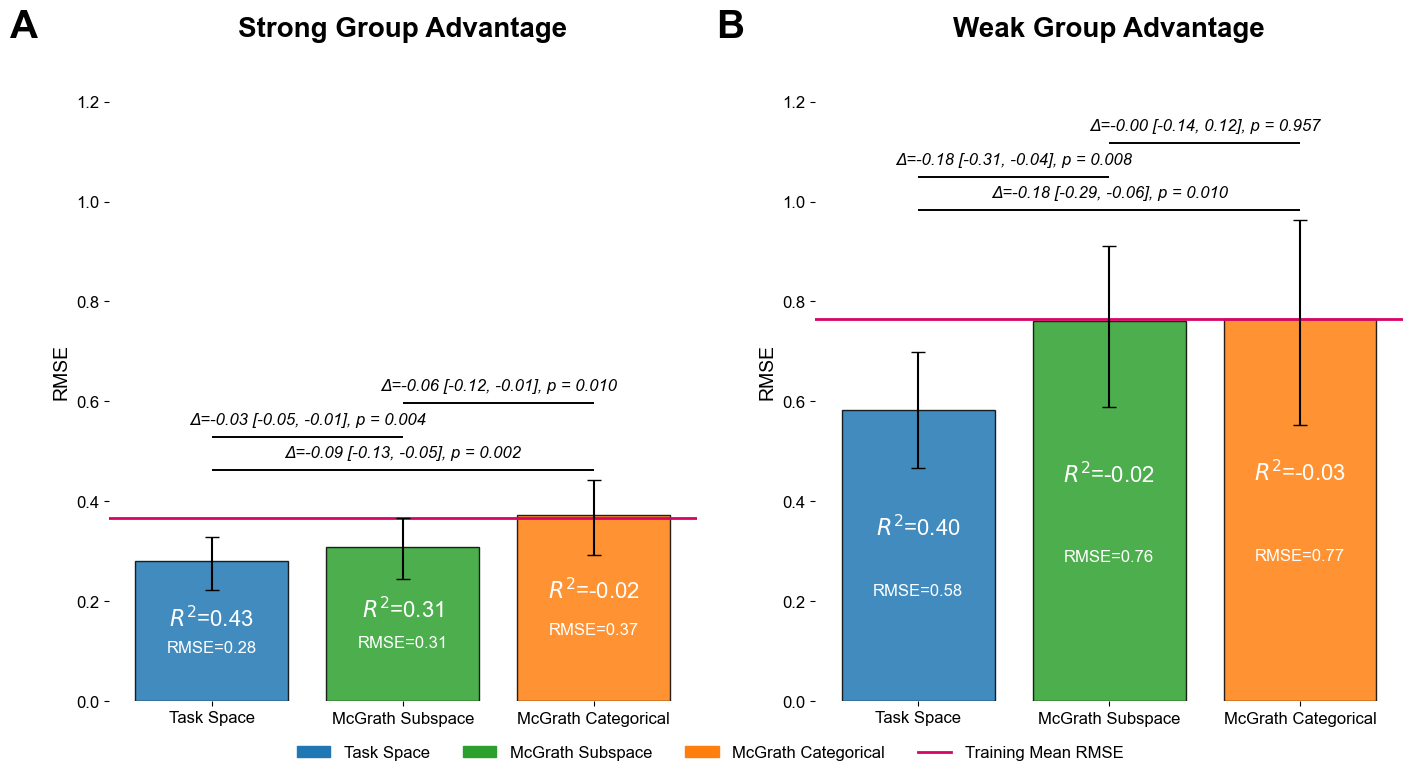

In [ ]:
plot_group_advantage_rmse_with_r2(
	MODELS, "Wave 2", TRAIN_TEST_DATA, custom_r2,
	["Task Space", "McGrath Subspace", "McGrath Categorical"],
	models_to_plot= ["E-Net"],
	ivs_to_compare = [
		("Task Space", "McGrath Categorical"),
		("Task Space", "McGrath Subspace"),
		("McGrath Subspace", "McGrath Categorical")
		]
)

## Supplemental Figures

Pairwise Comparison Results:
OLS | strong | Task Space vs McGrath Categorical: (t = -181.454, SE = 0.000, 95% CI [-0.093, -0.044], p = 0.002, N = 1,000)
OLS | strong | Task Space vs McGrath Subspace: (t = -34.187, SE = 0.001, 95% CI [-0.070, 0.017], p = 0.300, N = 1,000)
OLS | strong | McGrath Subspace vs McGrath Categorical: (t = -49.075, SE = 0.001, 95% CI [-0.103, 0.013], p = 0.140, N = 1,000)
OLS | weak | Task Space vs McGrath Categorical: (t = -55.817, SE = 0.002, 95% CI [-0.239, 0.021], p = 0.092, N = 1,000)
OLS | weak | Task Space vs McGrath Subspace: (t = -107.320, SE = 0.001, 95% CI [-0.186, -0.042], p = 0.002, N = 1,000)
OLS | weak | McGrath Subspace vs McGrath Categorical: (t = 1.584, SE = 0.002, 95% CI [-0.115, 0.130], p = 0.965, N = 1,000)


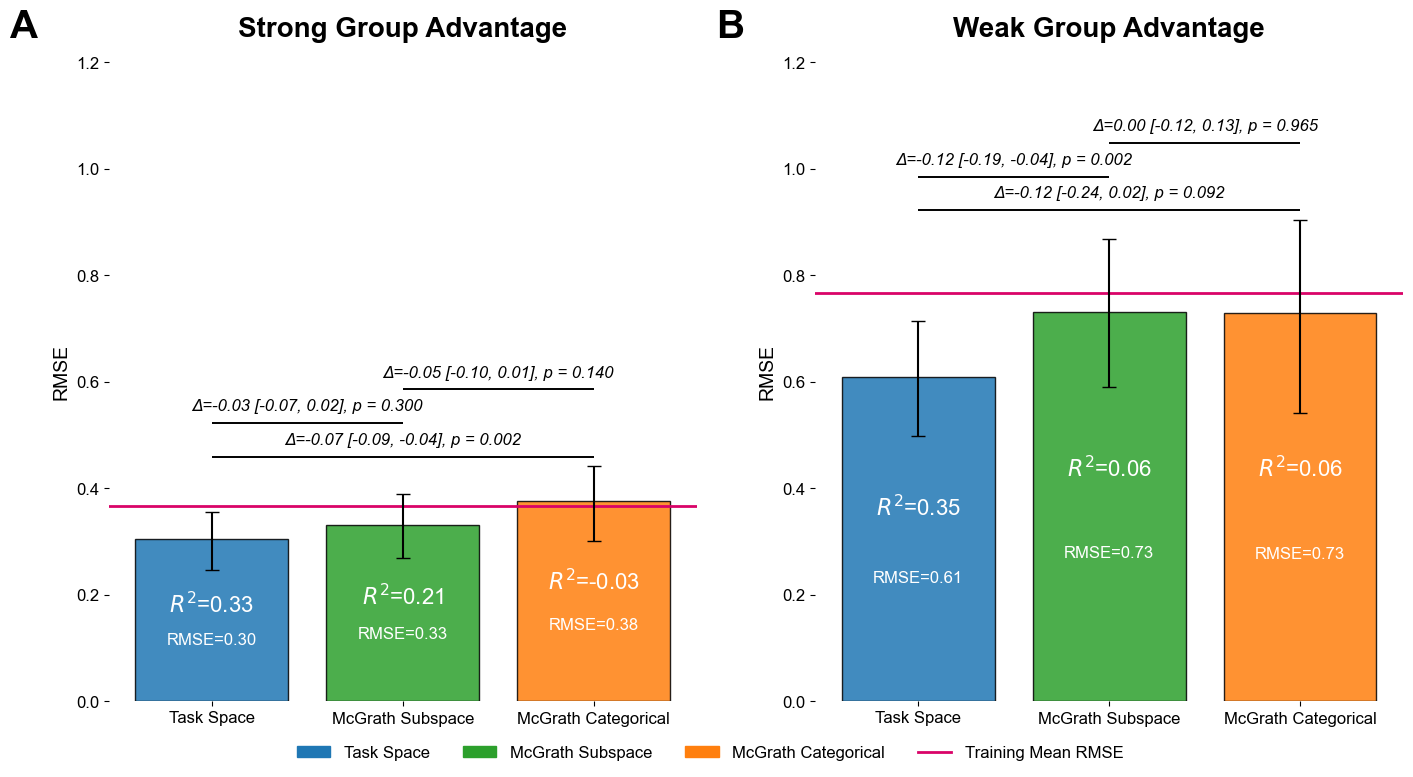

In [343]:
plot_group_advantage_rmse_with_r2(
	MODELS, "Wave 2", TRAIN_TEST_DATA, custom_r2,
	["Task Space", "McGrath Subspace", "McGrath Categorical"],
	models_to_plot= ["OLS"],
	ivs_to_compare = [
		("Task Space", "McGrath Categorical"),
		("Task Space", "McGrath Subspace"),
		("McGrath Subspace", "McGrath Categorical")
		]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Pairwise Comparison Results:
NN | strong | Task Space vs McGrath Categorical: (t = -101.388, SE = 0.001, 95% CI [-0.135, -0.033], p = 0.002, N = 1,000)
NN | strong | Task Space vs McGrath Subspace: (t = -11.978, SE = 0.001, 95% CI [-0.050, 0.039], p = 0.695, N = 1,000)
NN | strong | McGrath Subspace vs McGrath Categorical: (t = -119.546, SE = 0.001, 95% CI [-0.114, -0.036], p = 0.002, N = 1,000)
NN | weak | Task Space vs McGrath Categorical: (t = -91.379, SE = 0.002, 95% CI [-0.296, -0.052], p = 0.012, N = 1,000)
NN | weak | Task Space vs McGrath Subspace: (t = -110.461, SE = 0.002, 95% CI [-0.293, -0.078], p = 0.002, N = 1,000)
NN | weak | McGrath Subspace vs McGrath Categorical: (t = 3.049, SE = 0.002, 95% CI [-0.124, 0.133], p = 0.907, N = 1,000)


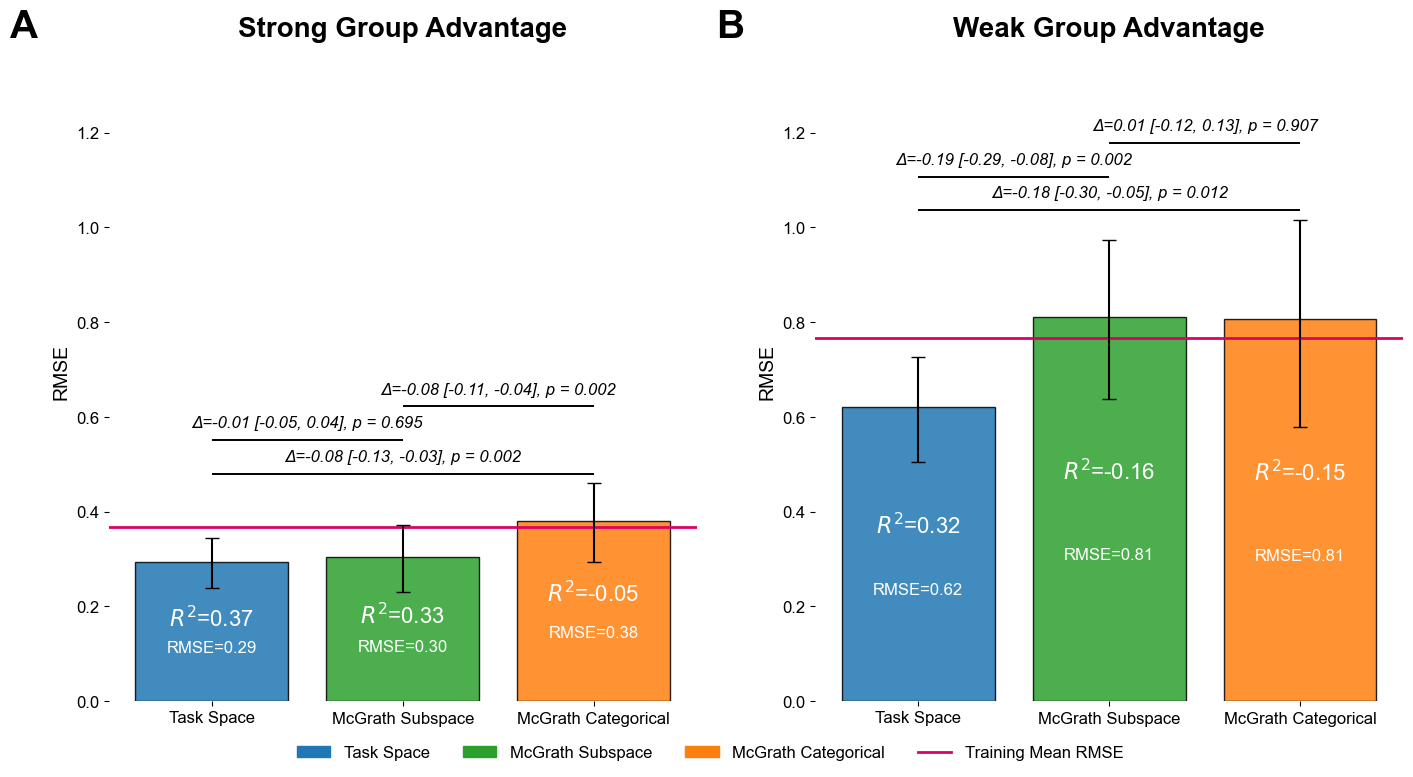

In [344]:
plot_group_advantage_rmse_with_r2(
	MODELS, "Wave 2", TRAIN_TEST_DATA, custom_r2,
	["Task Space", "McGrath Subspace", "McGrath Categorical"],
	models_to_plot= ["NN"],
	ivs_to_compare = [
		("Task Space", "McGrath Categorical"),
		("Task Space", "McGrath Subspace"),
		("McGrath Subspace", "McGrath Categorical")
		]
)

Pairwise Comparison Results:
E-Net | strong | Task Space vs Steiner Subspace: (t = -170.863, SE = 0.000, 95% CI [-0.082, -0.038], p = 0.002, N = 1,000)
E-Net | strong | Task Space vs Laughlin Subspace: (t = -42.993, SE = 0.001, 95% CI [-0.081, 0.013], p = 0.192, N = 1,000)
E-Net | strong | Steiner Subspace vs Laughlin Subspace: (t = 49.697, SE = 0.001, 95% CI [-0.006, 0.063], p = 0.136, N = 1,000)
E-Net | weak | Task Space vs Steiner Subspace: (t = -113.152, SE = 0.001, 95% CI [-0.130, -0.038], p = 0.002, N = 1,000)
E-Net | weak | Task Space vs Laughlin Subspace: (t = -82.549, SE = 0.002, 95% CI [-0.279, -0.038], p = 0.012, N = 1,000)
E-Net | weak | Steiner Subspace vs Laughlin Subspace: (t = -43.347, SE = 0.002, 95% CI [-0.171, 0.038], p = 0.166, N = 1,000)
OLS | strong | Task Space vs Steiner Subspace: (t = -48.922, SE = 0.001, 95% CI [-0.102, 0.013], p = 0.128, N = 1,000)
OLS | strong | Task Space vs Laughlin Subspace: (t = -24.429, SE = 0.002, 95% CI [-0.137, 0.060], p = 0.450, N =

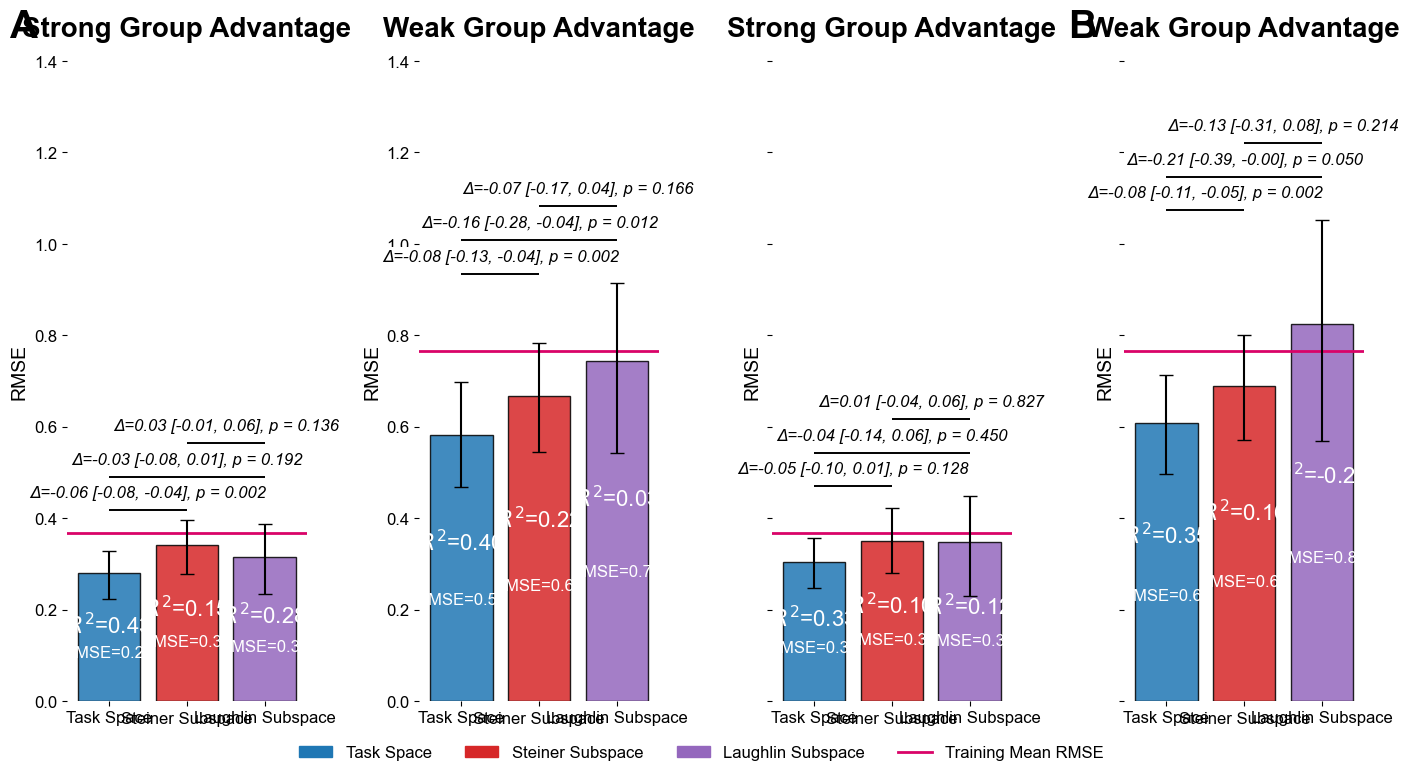

In [335]:
# supplementary figure with Steiner and Laughlin subspaces
plot_group_advantage_rmse_with_r2(
	MODELS, "Wave 2", TRAIN_TEST_DATA, custom_r2,
	["Task Space", "Steiner Subspace", "Laughlin Subspace"],
	models_to_plot= ["E-Net", "OLS"],
	ivs_to_compare = [
		("Task Space", "Steiner Subspace"),
		("Task Space", "Laughlin Subspace"),
		("Steiner Subspace", "Laughlin Subspace")
		]
)

### Pairwise RMSE Differences

In [356]:
def plot_pairwise_rmse_differences_within_model(
	MODELS, wave, DATA, custom_r2, ivs_selected,
	models_to_compare=("E-Net",),
	ivs_to_compare=None,
	dvs=("strong", "weak"),
	NUM_BOOTSTRAP_SAMPLES=1000,
	rmse_fn_map={"OLS": get_rmse_ols, "E-Net": get_rmse_for_enet, "NN": get_rmse_for_nn_keras}
):
	rng = np.random.default_rng(seed=19104)
	fs = 16  # unified font size

	def _default_rmse_fn(model, X_test, y_true, ivs):
		X_in = X_test[ivs]
		y_pred = model.predict(X_in) if hasattr(model, "predict") else model(X_in)
		y_pred = np.asarray(y_pred).ravel()
		return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

	def _get_rmse_fn(model_name):
		return rmse_fn_map.get(model_name, _default_rmse_fn)

	def get_ivs_from_label(iv_label):
		if iv_label == "Task Space":
			return basic_IVs
		if iv_label == "McGrath Categorical":
			return categorical_IVs
		if iv_label == "McGrath Subspace":
			return mcgrath_continuous
		if iv_label == "Steiner Subspace":
			return steiner_continuous
		if iv_label == "Laughlin Subspace":
			return laughlin_continuous
		raise ValueError(f"Unknown IV type: {iv_label}")

	if ivs_to_compare is None or len(ivs_to_compare) == 0:
		raise ValueError("ivs_to_compare must contain at least one IV pair.")

	# Collect all IVs needed
	all_needed_ivs = set(ivs_selected)
	for iv1, iv2 in ivs_to_compare:
		all_needed_ivs.add(iv1)
		all_needed_ivs.add(iv2)

	# Precompute bootstrap indices per dv
	boot_indices = {}
	n_test = len(DATA[wave]["test"])
	for dv in dvs:
		boot_indices[dv] = [rng.integers(0, n_test, size=n_test) for _ in range(NUM_BOOTSTRAP_SAMPLES)]

	# Bootstrap RMSEs for each (iv, model, dv)
	boot_rmse_map = {}
	for iv in all_needed_ivs:
		ivs_cols = get_ivs_from_label(iv)
		for model in models_to_compare:
			for dv in dvs:
				try:
					mdl = MODELS[iv][model][wave][dv]
				except Exception:
					continue
				Xtest = DATA[wave]["test"]
				y = Xtest[dv].values
				rmse_fn = _get_rmse_fn(model)

				boot_vals = []
				for idx in boot_indices[dv]:
					Xb = Xtest.iloc[idx]
					yb = y[idx]
					boot_vals.append(rmse_fn(mdl, Xb, yb, ivs_cols))
				boot_rmse_map[(iv, model, dv)] = np.asarray(boot_vals, dtype=float)

	# Pairwise differences: ΔRMSE = RMSE(iv1) − RMSE(iv2)
	pairwise_records = []
	for dv in dvs:
		for iv1, iv2 in ivs_to_compare:
			pair_label = f"{iv1} - {iv2}"
			for m in models_to_compare:
				k1, k2 = (iv1, m, dv), (iv2, m, dv)
				if k1 not in boot_rmse_map or k2 not in boot_rmse_map:
					continue
				a1, a2 = boot_rmse_map[k1], boot_rmse_map[k2]
				n = min(len(a1), len(a2))
				diffs = a1[:n] - a2[:n]
				diffs = diffs[np.isfinite(diffs)]
				if len(diffs) == 0:
					continue

				pairwise_records.append(pd.DataFrame({
					"dv": dv,
					"iv1": iv1,
					"iv2": iv2,
					"model": m,
					"pair_label": pair_label,
					"diff": diffs
				}))

	if not pairwise_records:
		raise ValueError("No valid pairwise comparisons were generated. Check ivs_to_compare and model availability.")

	df_diffs = pd.concat(pairwise_records, ignore_index=True)

	# Title-case DV labels and enforce exactly two facets: left=Strong, right=Weak
	dv_title_map = {dv: dv.title() for dv in dvs}
	df_diffs["dv_title"] = df_diffs["dv"].map(dv_title_map)
	dv_order = [dvs[0].title()] + ([dvs[1].title()] if len(dvs) > 1 else [])

	# Fixed order for legend/colors
	pair_labels_order = [
		"Task Space - McGrath Subspace",
		"Task Space - McGrath Categorical",
		"McGrath Subspace - McGrath Categorical"
	]
	df_diffs["pair_label"] = pd.Categorical(df_diffs["pair_label"], categories=pair_labels_order, ordered=True)

	palette = sns.color_palette("colorblind", n_colors=len(pair_labels_order))
	color_map = dict(zip(pair_labels_order, palette))

	# Build the two facets (left/right)
	g = sns.FacetGrid(
		df_diffs,
		col="dv_title",
		col_order=dv_order,
		sharex=True,
		sharey=False,
		height=4,
		aspect=1.6,
		margin_titles=False
	)

	# Plot three overlays per facet: filled hist + KDE for each comparison
	def _plot_overlays(data, **kwargs):
		ax = plt.gca()
		for label in pair_labels_order:
			sub = data[data["pair_label"] == label]
			if sub.empty:
				continue
			sns.histplot(
				data=sub,
				x="diff",
				bins=30,
				stat="density",
				alpha=0.35,
				color=color_map[label],
				edgecolor=None,
				ax=ax
			)
			sns.kdeplot(
				data=sub,
				x="diff",
				color=color_map[label],
				lw=2,
				ax=ax
			)

	g.map_dataframe(_plot_overlays)

	# Vertical reference line at x = 0 (dotted to match legend)
	for ax in g.axes.flat:
		if ax is not None:
			ax.axvline(0, color="black", linestyle=":", linewidth=2, alpha=0.9)

	# Axis labels and titles (all font sizes = 16)
	for ax in g.axes.flat:
		if ax is not None:
			ax.set_xlabel("ΔRMSE (IV1 - IV2)", fontsize=fs)
			ax.set_ylabel("Density", fontsize=fs)
			ax.tick_params(axis="both", labelsize=fs)
	for ax, dv_title in zip(g.axes.flat, g.col_names):
		if ax is not None:
			ax.set_title(f"{dv_title} Group Advantage", fontsize=fs)

	# Custom legend (three comparisons + dotted zero line), one skinny row beneath both facets
	from matplotlib.lines import Line2D
	handles = [Line2D([0], [0], color=color_map[label], lw=3) for label in pair_labels_order]
	labels = list(pair_labels_order)
	# Add dotted zero line
	handles.append(Line2D([0], [0], color="black", lw=2, linestyle=":"))
	labels.append("ΔRMSE = 0")

	leg = g.fig.legend(
		handles,
		labels,
		loc="lower center",
		ncol=2,
		frameon=False,
		bbox_to_anchor=(0.5, -0.05),
		prop={"size": fs}
	)

	# Make room for the legend
	g.fig.subplots_adjust(bottom=0.32)

	plt.show()

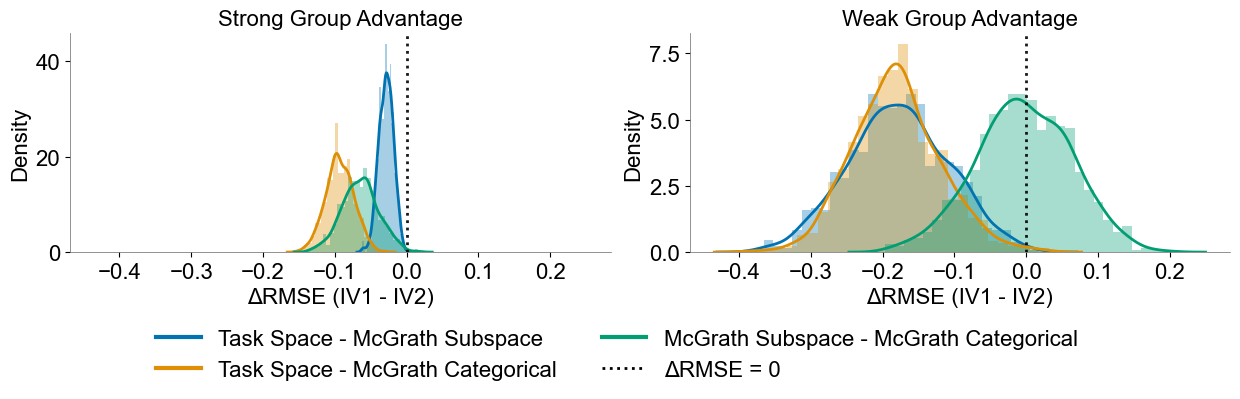

In [357]:
plot_pairwise_rmse_differences_within_model(
	MODELS, "Wave 2", TRAIN_TEST_DATA, custom_r2,
	["Task Space", "McGrath Subspace", "McGrath Categorical"],
	models_to_compare=["E-Net"],
	ivs_to_compare=[
		("Task Space", "McGrath Categorical"),
		("Task Space", "McGrath Subspace"),
		("McGrath Subspace", "McGrath Categorical")
	]
)

## Permutation/SHAP Interpretation Plots

In [ ]:
def model_predict(fitted_model, X, model_type):
	if model_type == "LM":
		X = sm.add_constant(X, has_constant='add')
		return fitted_model.predict(X)
	elif model_type == "NN":
		return fitted_model.predict(X).flatten()
	elif model_type == "E-Net":
		X = add_interactions(X)
		return fitted_model.predict(X)

In [ ]:
def plot_combined_feature_importance(
	model, wave_a_data, wave_b_data, ivs, dv_type, model_type, 
	save_path='./visualizations/combined_importance.png', n_repeats=100):
	
	set_random_seeds()

	X_test = wave_b_data[ivs].copy()
	y_test = wave_b_data[dv_type].values
	y_pred = model_predict(model, X_test, model_type)
	base_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

	# Map features to their groups using the provided dictionary
	feature_to_group = {}
	for key, group_name in pretty_feature_cluster_names.items():
		try:
			feature_list = ast.literal_eval(key)
			features = feature_list if isinstance(feature_list, list) else [feature_list]
		except (ValueError, SyntaxError):
			features = [key]
		for feature in features:
			feature_to_group[feature] = group_name

	# Create a mapping from groups to features
	group_to_features = {}
	for feature in ivs:
		group_name = feature_to_group.get(feature, feature)
		group_to_features.setdefault(group_name, []).append(feature)
		feature_to_group[feature] = group_name

	groups = list(group_to_features.keys())
	importances = np.zeros(len(groups))
	conf_intervals = np.zeros(len(groups))

	# Calculate permutation feature importance for each group
	for i, group_name in enumerate(groups):
		features_in_group = group_to_features[group_name]
		scores = np.zeros(n_repeats)
		for n in range(n_repeats):
			X_permuted = X_test.copy()
			permutation = np.random.permutation(len(X_test))
			for feature in features_in_group:
				X_permuted[feature] = X_permuted[feature].values[permutation]
			y_permuted_pred = model_predict(model, X_permuted, model_type)
			permuted_rmse = np.sqrt(mean_squared_error(y_test, y_permuted_pred))
			scores[n] = ((permuted_rmse - base_rmse) / base_rmse) * 100
		importances[i] = scores.mean()
		conf_intervals[i] = 1.96 * scores.std(ddof=1) / np.sqrt(n_repeats)

	exclude_groups = ["Generate", "High", "Medium", "Low", "playerCount"]
	display_indices = [i for i, group_name in enumerate(groups) if group_name not in exclude_groups]
	importances_display = importances[display_indices]
	conf_intervals_display = conf_intervals[display_indices]
	groups_display = [groups[i] for i in display_indices]

	sorted_indices = np.argsort(importances_display)
	sorted_group_names = np.array(groups_display)[sorted_indices]
	importances_sorted = importances_display[sorted_indices]
	conf_intervals_sorted = conf_intervals_display[sorted_indices]
	
	# Configure matplotlib for the desired style
	plt.style.use('default')
	matplotlib.rcParams.update({
		'figure.figsize': (40, 4.72),
		'font.size': 18,
		'font.sans-serif': ['Arial'],
		'axes.facecolor': 'white',
		'axes.edgecolor': '#666666',
		'axes.linewidth': 0.5,
		'grid.alpha': 0.0,
		'pdf.fonttype': 42,
		'ps.fonttype': 42
	})
	
	# Define the figure and grid specs for the plots
	fig = plt.figure(figsize=(40, 4.72), dpi=300)
	gs = plt.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.2)
	ax_left = fig.add_subplot(gs[0])
	ax_right = fig.add_subplot(gs[1], sharey=ax_left)  # Use sharey for alignment

	# Left plot
	ax_left.barh(
		range(len(sorted_group_names)),
		importances_sorted,
		xerr=conf_intervals_sorted,
		align='center',
		alpha=0.7,
		capsize=3,
		height=0.9,
		color="#1f77b4"# ,
		# edgecolor='k'
	)
	ax_left.set_yticks(range(len(sorted_group_names)))
	ax_left.set_yticklabels(sorted_group_names, fontsize=22)
	ax_left.invert_yaxis()
	ax_left.set_xlabel("Feature Importance\n(% Change in RMSE)", fontsize=22)
	ax_left.axvline(x=0, linestyle='--', color='#666666', linewidth=0.8, zorder=0)
	ax_left.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

	# Remove top and right spines
	ax_left.spines['top'].set_visible(False)
	ax_left.spines['right'].set_visible(False)

	# Adjust tick parameters
	ax_left.tick_params(axis='y', which='major', labelsize=22, length=3, width=0.5)
	ax_left.tick_params(axis='x', which='major', labelsize=22, length=3, width=0.5)
	ax_left.set_ylim(-0.5, len(sorted_group_names) - 0.5)

	explainer = shap.Explainer(lambda inputs: model_predict(model, inputs, model_type), X_test)
	shap_values = explainer(X_test)

	shap_values_df = pd.DataFrame(shap_values.values, columns=shap_values.feature_names)
	feature_values_df = pd.DataFrame(shap_values.data, columns=shap_values.feature_names)

	# Group SHAP values and feature values by the defined groups
	grouped_shap_values_df = pd.DataFrame(index=shap_values_df.index)
	grouped_feature_values = pd.DataFrame(index=feature_values_df.index)
	for group_name, features in group_to_features.items():
		existing_features = [f for f in features if f in shap_values.feature_names]
		if existing_features:
			grouped_shap_values_df[group_name] = shap_values_df[existing_features].sum(axis=1)
			grouped_feature_values[group_name] = feature_values_df[existing_features].mean(axis=1)

	grouped_shap_values_df = grouped_shap_values_df[[col for col in grouped_shap_values_df.columns if col not in exclude_groups]]
	grouped_feature_values = grouped_feature_values[[col for col in grouped_feature_values.columns if col not in exclude_groups]]

	# Sort SHAP values according to importance order
	sorted_group_order = [group for group in sorted_group_names if group in grouped_shap_values_df.columns][::-1]
	order = [grouped_shap_values_df.columns.get_loc(group) for group in sorted_group_order]

	# Create a SHAP Explanation object
	explanation = shap.Explanation(
		values=grouped_shap_values_df.values,
		base_values=shap_values.base_values,
		data=grouped_feature_values.values,
		feature_names=grouped_shap_values_df.columns
	)

	# Right plot using SHAP beeswarm
	plt.sca(ax_right)
	shap.plots.beeswarm(
		explanation,
		show=False,
		color_bar=True,
		max_display=len(order),
		alpha=0.5,
		order=order
	)
	
	# format the x-axis with one decimal place
	ax = plt.gca()
	ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))

	# Hide y-tick labels on the right, maintain shared y-axis alignment
	ax_right.tick_params(axis='y', labelleft=False)
	ax_right.tick_params(axis='x', labelsize=22)

	# Adjust the colorbar labels and tick parameters
	fig = plt.gcf()
	fig.set_size_inches(12, 8) # set figure size
	for obj in fig.get_children():
		if isinstance(obj, plt.Axes) and 'colorbar' in obj.get_label():
			obj.tick_params(labelsize=22)
			obj.set_ylabel(obj.get_ylabel(), fontsize=22)

	# Style adjustments for the right plot
	ax_right.set_xlabel("SHAP Value\n(Impact on Model Output)", fontsize=22, labelpad=10)

	plt.tight_layout()
	plt.savefig(save_path, dpi=300, bbox_inches='tight', metadata={'Creator': 'Matplotlib'})
	plt.show()

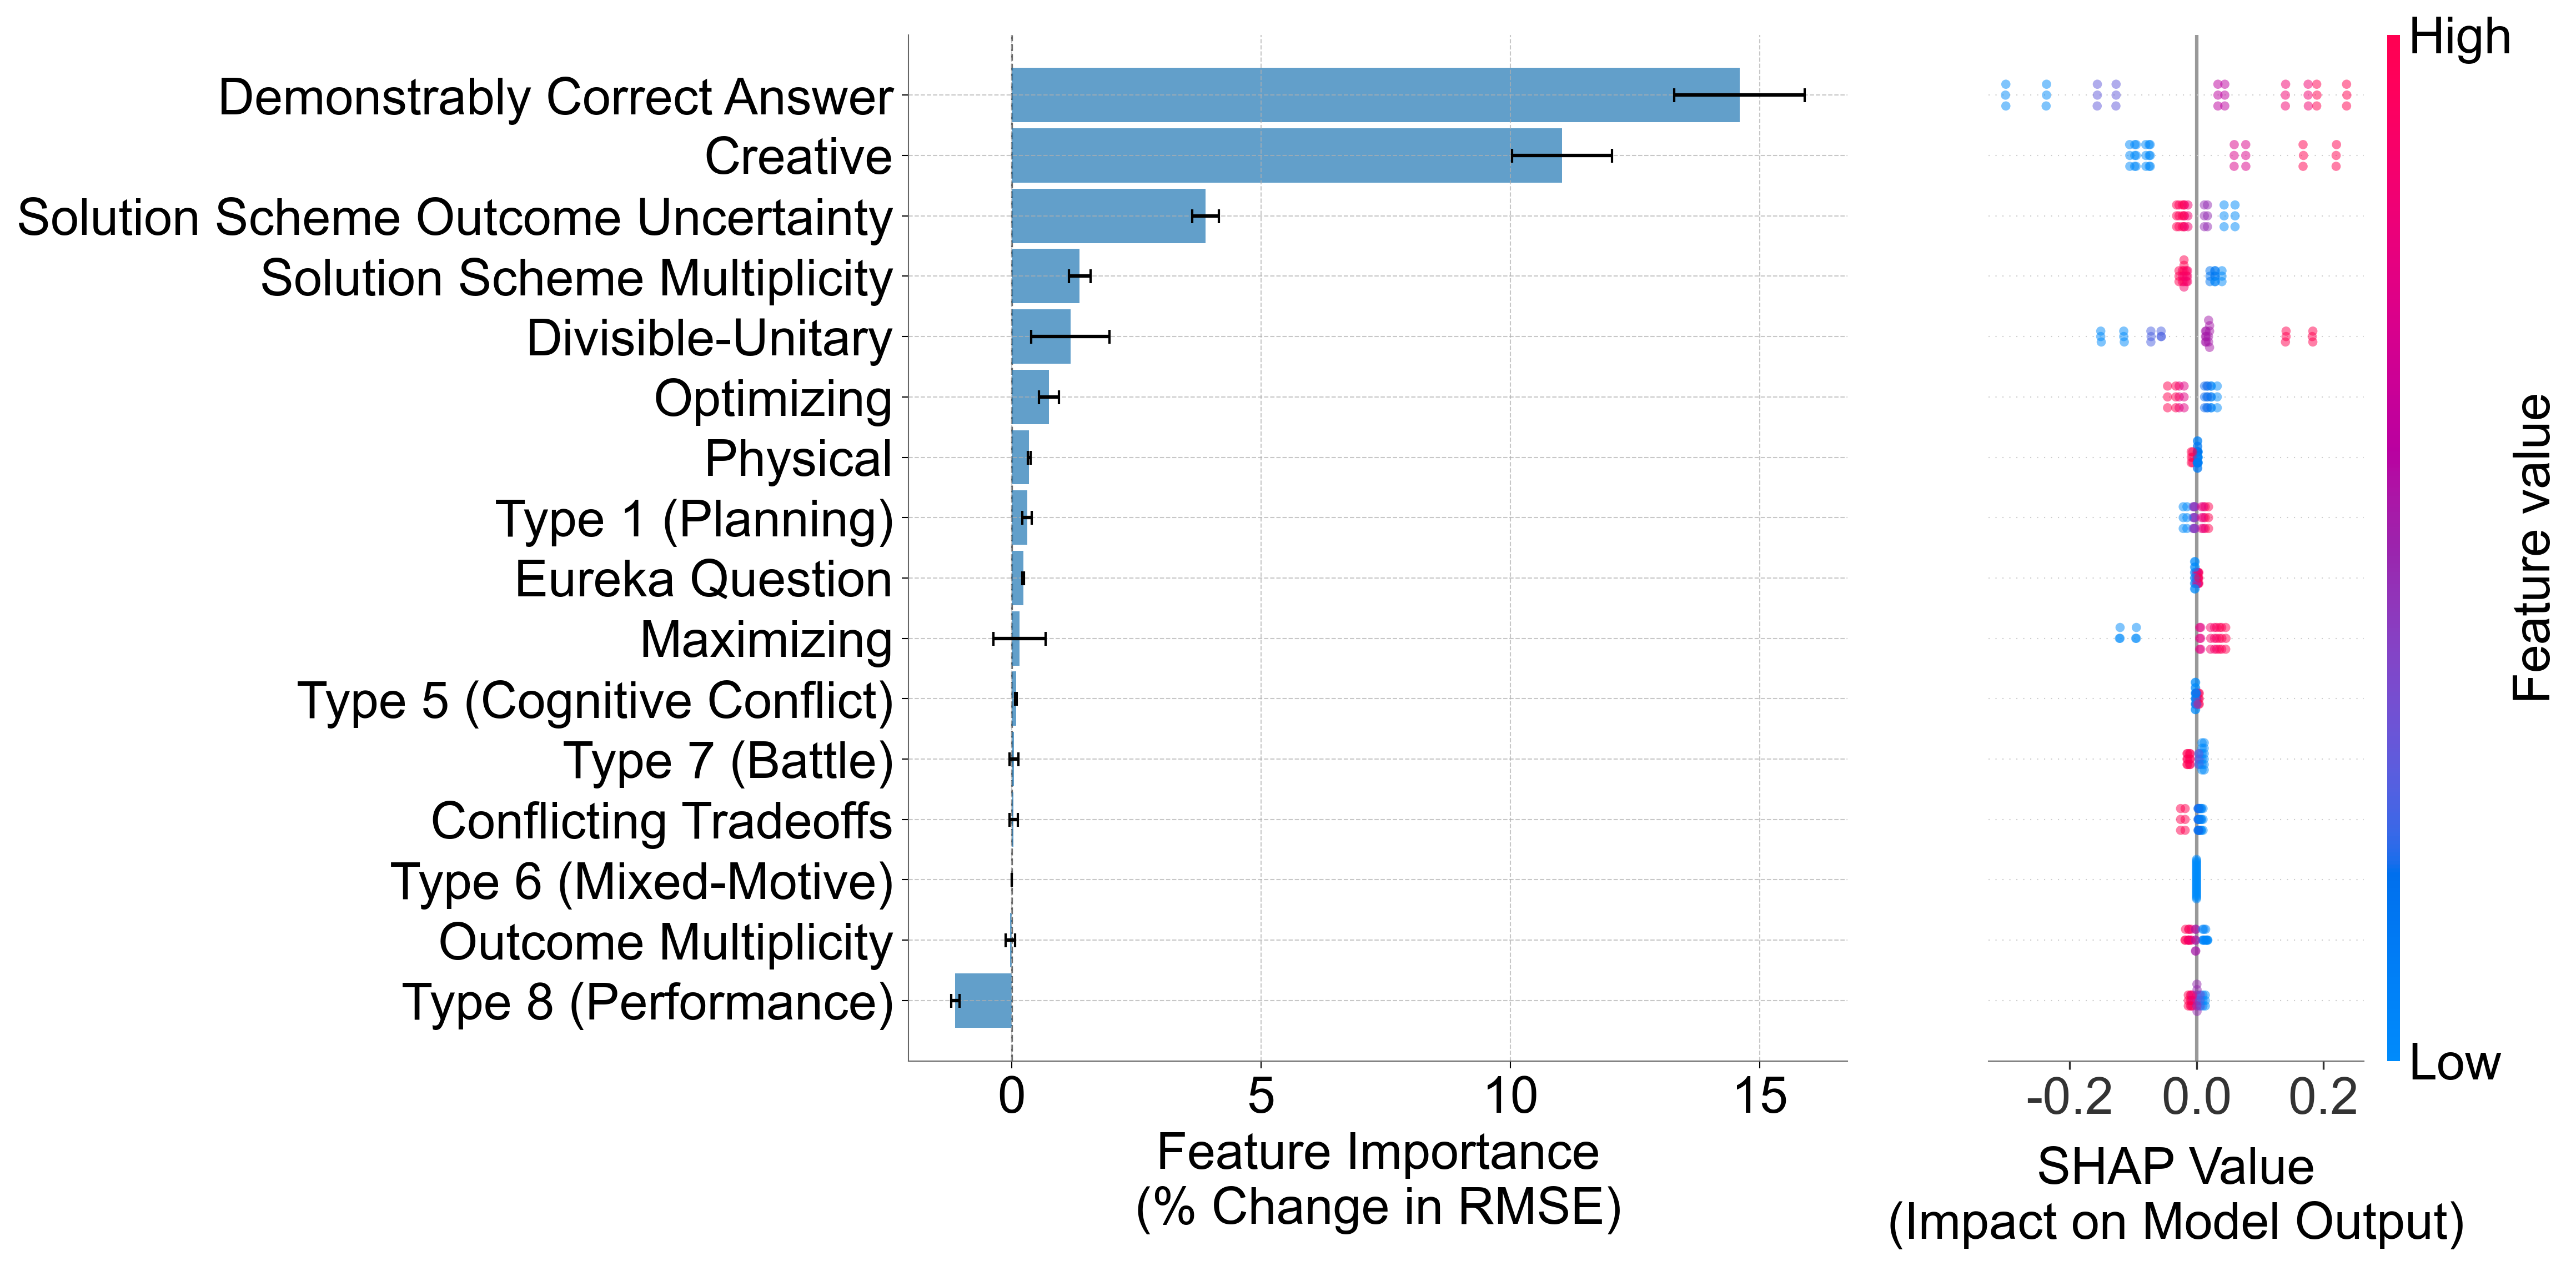

In [ ]:
# ENet with interactions - Weak Synergy (Train Waves 1-2, Predict Wave 3)
plot_combined_feature_importance(
	model = MODELS["Task Space"]["E-Net"]["Wave 2"]["weak"],
	wave_a_data = TRAIN_TEST_DATA["Wave 2"]["train"],
	wave_b_data = TRAIN_TEST_DATA["Wave 2"]["test"],
	ivs = basic_IVs,
	dv_type = "weak",
	model_type = "E-Net",
	save_path = '../outputs/combined_importance_enet_weak_wave3.png'
)

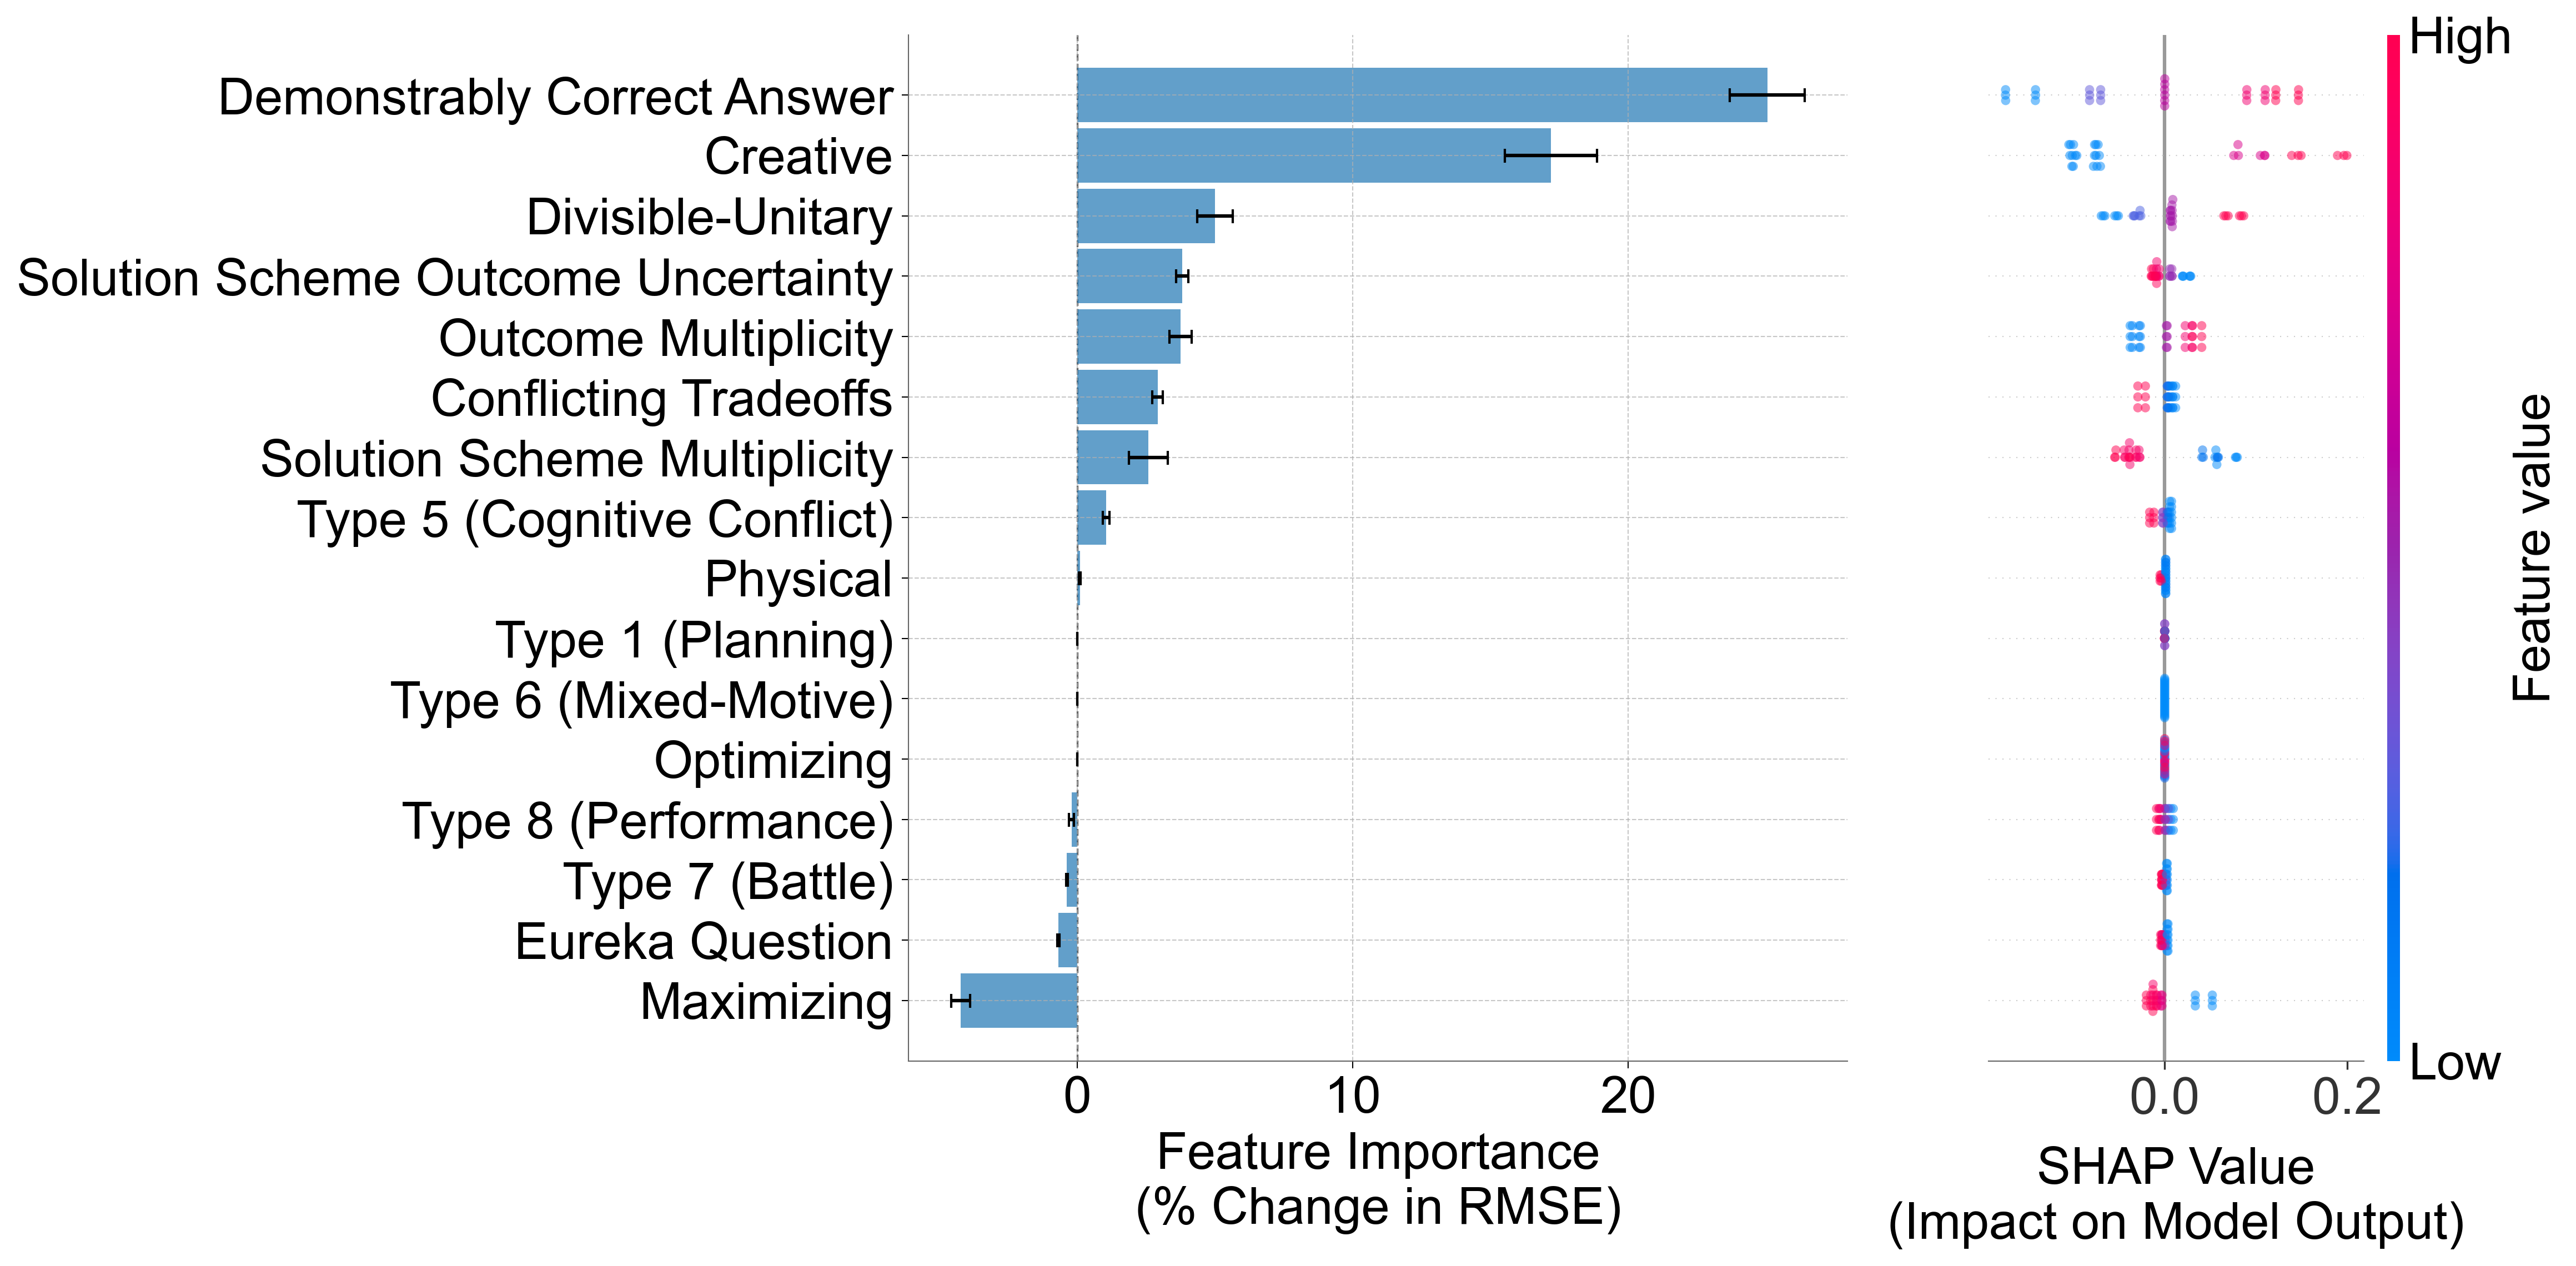

In [ ]:
# E-Net - Strong Synergy (Train Waves 1-2, Predict Wave 3)
plot_combined_feature_importance(
	model = MODELS["Task Space"]["E-Net"]["Wave 2"]["strong"],
	wave_a_data = TRAIN_TEST_DATA["Wave 2"]["train"],
	wave_b_data = TRAIN_TEST_DATA["Wave 2"]["test"],
	ivs = basic_IVs,
	dv_type = "strong",
	model_type = "E-Net",
	save_path = '../outputs/combined_importance_enet_strong_wave3.png'
)

# Robustness Checks

## Checking Robustness to Noise

In [ ]:
def plot_model_performance(data, y_label='RMSE', output_file='../outputs/model_performance'):
	"""
	Plot model performance against the number of affected columns for different noise levels, with baselines.
	Generates faceted plots for both 'strong' and 'weak' groups.

	Parameters:
	- data: dict, the dictionary containing model performance data.
	- y_label: str, label for the y-axis ('RMSE' or 'R^2').
	- output_file: str, path to save the plotted figure.
	"""
	noise_levels = [0.25, 0.5, 0.75, 1.0]
	affected_columns = sorted(data.keys())

	if y_label == 'RMSE':
		baselines = MODEL_RMSE_RESULTS
	else:
		baselines = MODEL_R2_RESULTS

	dv_types = ['strong', 'weak']
	dv_labels = ["DV: Strong Group Advantage", "DV: Weak Group Advantage"]

	fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 15), sharex=True)
	colors = plt.cm.Dark2(np.linspace(0, 1, len(noise_levels) + len(baselines)))

	for i, (ax, dv_type, dv_label) in enumerate(zip(axes, dv_types, dv_labels)):
		for idx, noise in enumerate(noise_levels):
			performance = [data[col][noise][dv_type] for col in affected_columns]
			ax.plot(affected_columns, performance, label=f'Noise SD={noise}', color=colors[idx])

		baseline_labels = ["Task Space", "McGrath Categorical", "McGrath Subspace"]
		for idx, label in enumerate(baseline_labels, start=len(noise_levels)):
			baseline_value = baselines[label]["E-Net"]["Wave 2"][dv_type]
			ax.axhline(y=baseline_value, color=colors[idx], linestyle='--', label=f'{label} Baseline')
			ax.text(max(affected_columns) + 0.2, baseline_value + 0.0001, f"{baseline_value:.2f}", color=colors[idx], fontsize=12)

		ax.set_ylabel(y_label, fontsize=14)
		ax.set_title(dv_label, fontsize=16)
		ax.grid(True)

		# Panel labels
		ax.text(-0.05, 1.05, f'{chr(65+i)}', transform=ax.transAxes, 
				fontsize=16, fontweight='bold', va='top', ha='right')

	plt.xticks(affected_columns, fontsize=14)
	plt.xlabel('Number of Task Columns Affected by Noise', fontsize=14)
	plt.suptitle(f'Model Performance ({y_label}) in Response to Training Data', fontsize=16)

	# Adjust legend to be below title
	handles, labels = axes[0].get_legend_handles_labels()
	fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=14, bbox_to_anchor=(0.5, 0.96), frameon=False)

	plt.tight_layout(rect=[0, 0.03, 1, 0.93])
	plt.savefig(output_file + ".png")
	plt.savefig(output_file + ".pdf")

	plt.show()

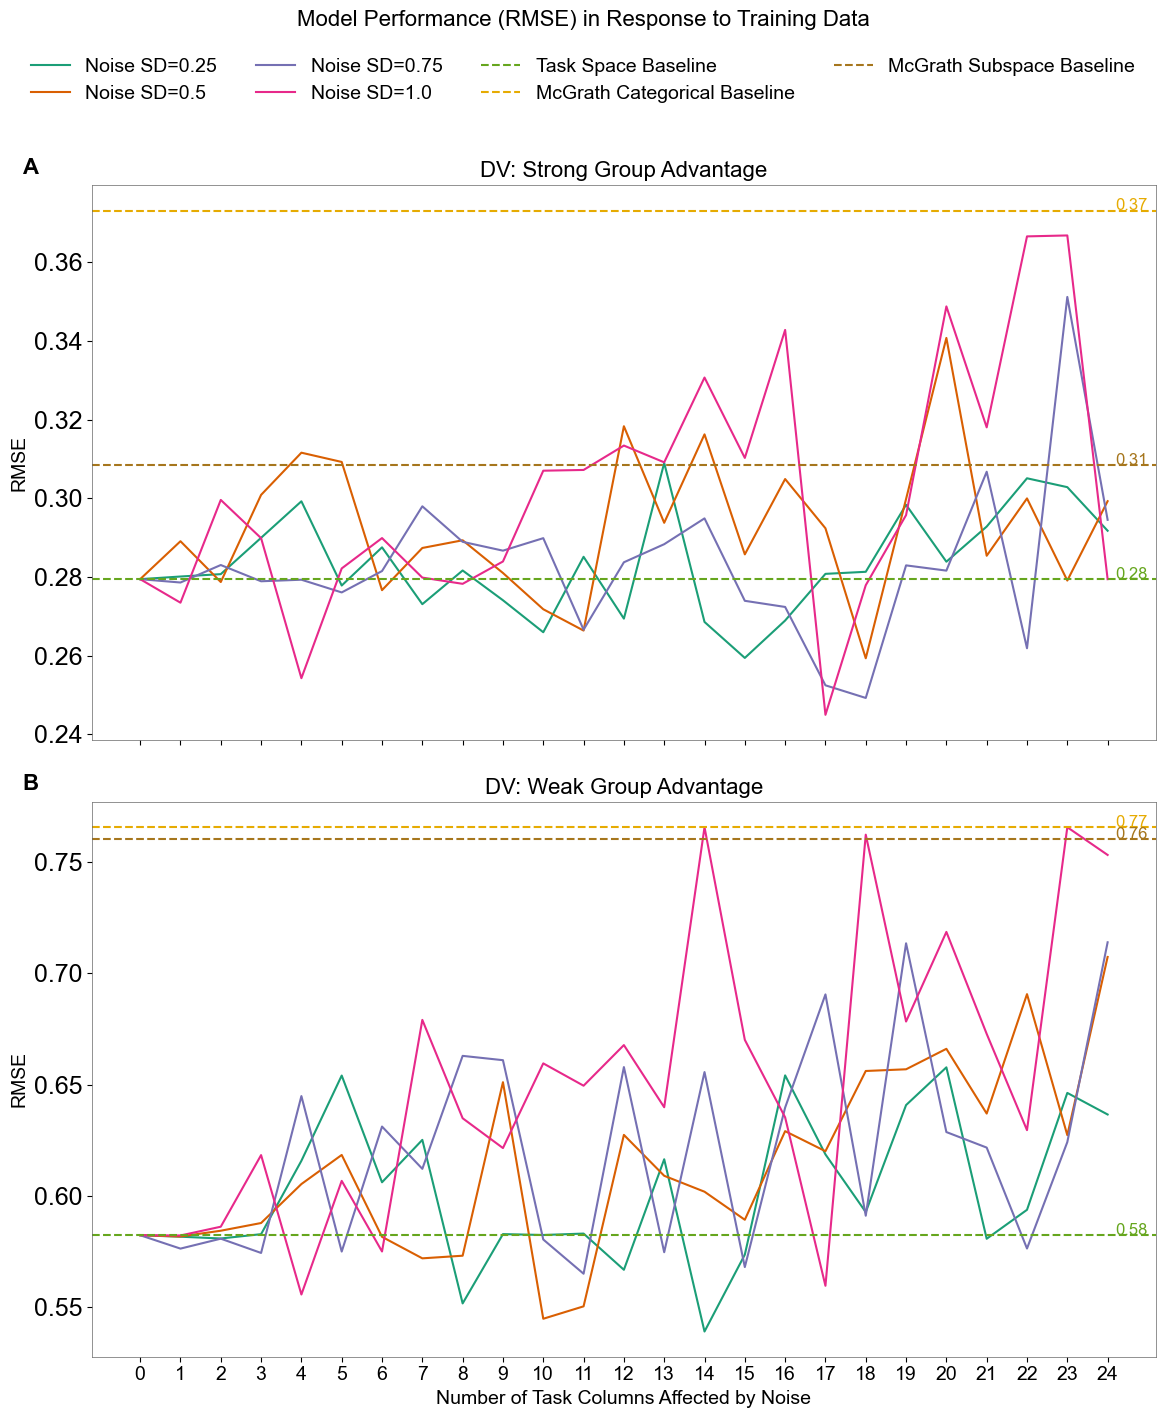

In [286]:
plot_model_performance(ENETS_NOISE_ROBUSTNESS_RMSE_RESULTS, y_label='RMSE', output_file='../outputs/enet_noise_robustness_rmse')

## Are Task Relationships Robust to Noise?

In [ ]:
""""
 WANT TO SHOW:
 Two features that are farther away in a lower-dimensional representation of the space should also be
 further away in a higher dimensional representation of the space.

 HOW TO SHOW:
 - Choose every possible combination of 3 tasks.
 - Measure whether cosine_distance(task 1, task 2) is smaller than cosine_distance(task 1, task 3)
	 - Positive if task 1 and task 2 are closer; Negative if 1 and 3 are closer
 - Ideally, all signs should be the same, so we'll return the % of signs that are the same

 This code is commented out because it takes several hours to run, but it is here for reproducibility. The
 saved output is read in as a .pkl file.

"""""
# consistency_dict_for_num_features = defaultdict(list)

# def process_tasks_for_combination(three_tasks, all_combinations_of_i_features):
#     try:
#         signs = []
#         for task_feature_combination in random.samatplotlibe(all_combinations_of_i_features, 10):
#             diff = check_similarity_robustness_examatplotlibe_3_tasks(
#                 list(task_feature_combination), three_tasks[0], three_tasks[1], three_tasks[2]
#             )
#             signs.append(np.sign(diff))

#         # Compare the signs to 'perfect performance'
#         modal_sign = mode(signs)
#         consistency_pct = np.mean([(item == modal_sign) for item in signs])
#         return consistency_pct

#     except Exception as e:
#         print(f"Error processing tasks for combination {three_tasks}: {e}")
#         return None

# for i in range(2, 24):
#     print(f"Starting experiments for {i} features...")
	
#     all_combinations_of_i_features = list(itertools.combinations(task_map.drop("task_name", axis=1).columns, i))
#     all_three_task_combinations = list(itertools.combinations(task_map["task_name"].drop_duplicates(), 3))
	
#     with tqdm(total=len(all_three_task_combinations), desc=f"Processing {i} features") as pbar:
#         with concurrent.futures.ThreadPoolExecutor(max_workers=multiprocessing.cpu_count()) as executor:
#             futures = [executor.submit(process_tasks_for_combination, three_tasks, all_combinations_of_i_features) 
#                        for three_tasks in all_three_task_combinations]
		  
#             for future in concurrent.futures.as_comatplotlibeted(futures):
#                 result = future.result()
#                 if result is not None:
#                     consistency_dict_for_num_features[i].append(result)
#                 pbar.update()

# # Save the dictionary to a file
# with open('./saved_outputs/consistency_dict_for_num_features.pkl', 'wb') as file:
#     pickle.dump(consistency_dict_for_num_features, file)

'"\n WANT TO SHOW:\n Two features that are farther away in a lower-dimensional representation of the space should also be\n further away in a higher dimensional representation of the space.\n\n HOW TO SHOW:\n - Choose every possible combination of 3 tasks.\n - Measure whether cosine_distance(task 1, task 2) is smaller than cosine_distance(task 1, task 3)\n\t - Positive if task 1 and task 2 are closer; Negative if 1 and 3 are closer\n - Ideally, all signs should be the same, so we\'ll return the % of signs that are the same\n\n This code is commented out because it takes several hours to run, but it is here for reproducibility. The\n saved output is read in as a .pkl file.\n\n'

In [ ]:
with open('../outputs/consistency_dict_for_num_features.pkl', 'rb') as file:
	consistency_dict_for_num_features = pickle.load(file)

# Initialize lists to store x-values (number of features), means, and CIs
num_features = []
means = []
lower_bounds = []
upper_bounds = []

# Calculate mean and 95% CI for each entry in the dictionary
for key, values in sorted(consistency_dict_for_num_features.items()):
	num_features.append(key)
	mean_val = np.mean(values)
	means.append(mean_val)
	
	# Calculate 95% CI
	n = len(values)
	if n > 1:  
		h = stats.sem(values) * stats.t.ppf((1 + 0.95) / 2, n - 1)
	else:
		h = 0  # In case of a single value, CI is zero (no spread)
	
	lower_bounds.append(mean_val - h)
	upper_bounds.append(mean_val + h)
	
def check_similarity_robustness_examatplotlibe_3_tasks(features, task_1 = "Moral Reasoning (Disciplinary Action Case)", task_2 = "Allocating resources to programs", task_3 = "Sudoku"):
	
	task_map_copy = pd.read_csv("./data/task_map.csv").rename(columns = {"task": "task_name"}).copy()

	# filter down to a set of features
	task_map_copy = task_map_copy[["task_name"] + features]
	
	task_1_vec = np.asarray(task_map_copy[task_map_copy["task_name"] == task_1].drop("task_name",axis=1)).flatten()
	task_2_vec = np.asarray(task_map_copy[task_map_copy["task_name"] == task_2].drop("task_name",axis=1)).flatten()
	task_3_vec = np.asarray(task_map_copy[task_map_copy["task_name"] == task_3].drop("task_name",axis=1)).flatten()
	
	# get similarity between task 1 and task 2
	vec_1_2_sim = distance.cosine(task_1_vec, task_2_vec)
	vec_1_3_sim = distance.cosine(task_2_vec, task_3_vec)

	# 1 and 2 are closer than 1 and 3
	diff = vec_1_3_sim-vec_1_2_sim

	return(diff)

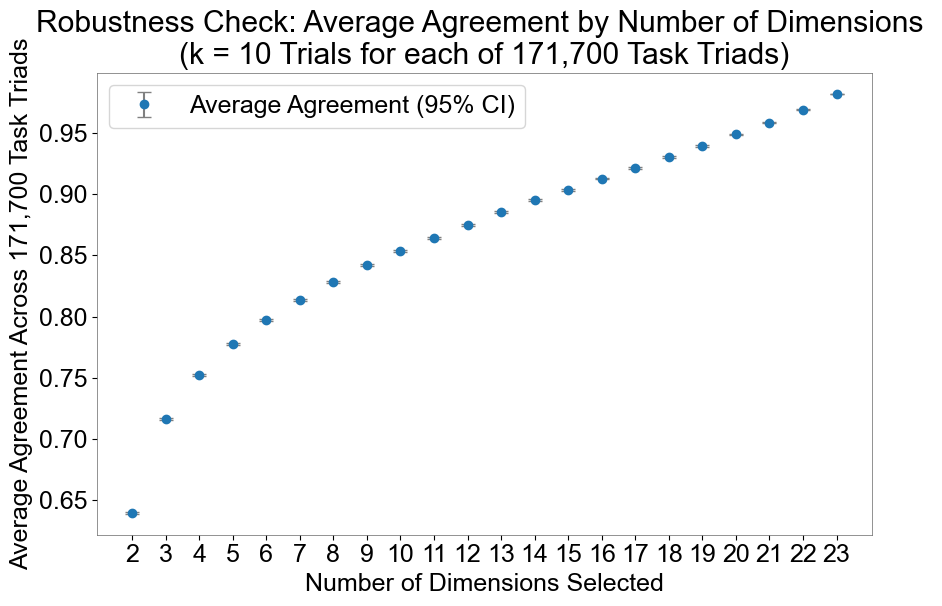

In [ ]:
plt.figure(figsize=(10, 6))
plt.errorbar(num_features, means, yerr=[np.array(means) - np.array(lower_bounds), np.array(upper_bounds) - np.array(means)], 
			 fmt='o', capsize=5, capthick=1, ecolor='gray', label='Average Agreement (95% CI)')
plt.xlabel('Number of Dimensions Selected')
plt.ylabel('Average Agreement Across 171,700 Task Triads')
plt.title('Robustness Check: Average Agreement by Number of Dimensions \n(k = 10 Trials for each of 171,700 Task Triads)')
plt.xticks(np.arange(min(num_features), max(num_features) + 1, 1))

plt.grid(True)
plt.legend()
plt.savefig('../outputs/robustness_check_average_agreement.png', dpi=300, bbox_inches='tight')
plt.savefig('../outputs/robustness_check_average_agreement.pdf', bbox_inches='tight')
plt.show()

# Task Map Heatmap

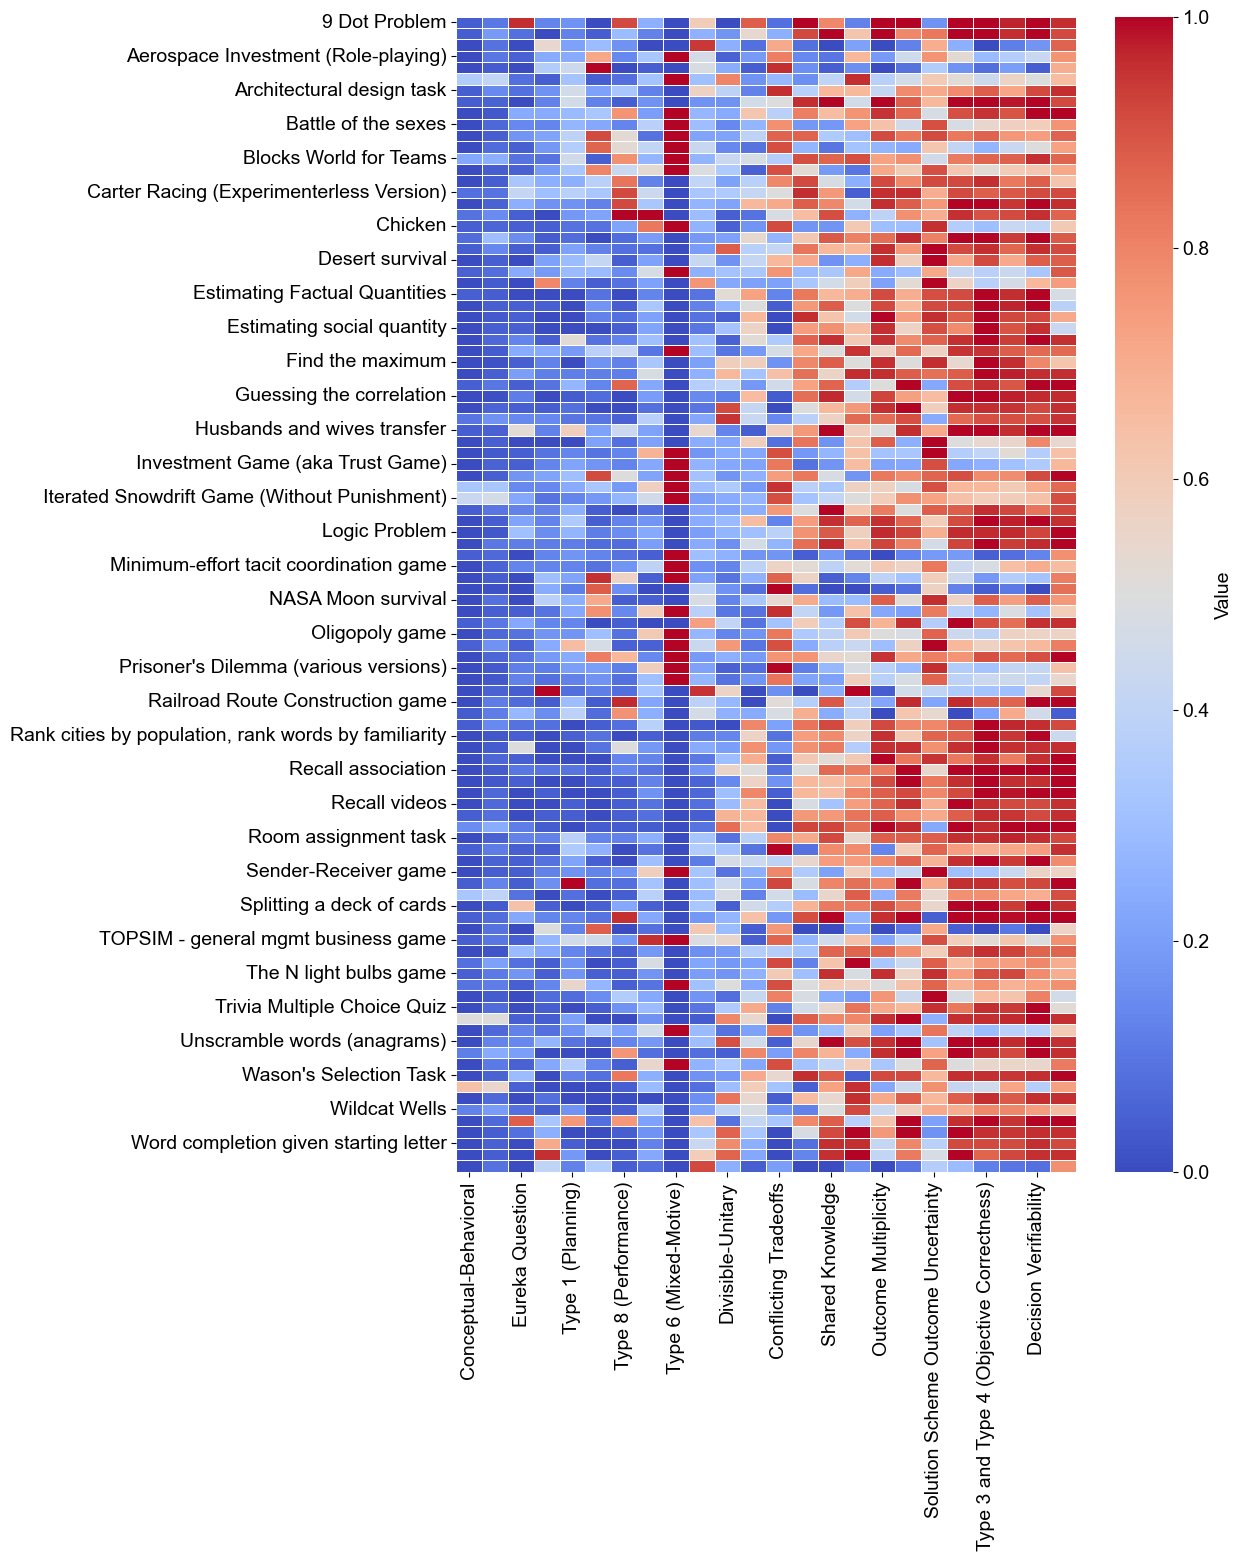

In [290]:
task_map = pd.read_csv("../data/task_map.csv").rename(columns={"task": "task_name"})
task_map.set_index('task_name', inplace=True)

# filter out _cat columns
task_map = task_map[[col for col in task_map.columns if "_cat" not in col]]

# Calculate the average values for each dimension
column_means = task_map.mean().sort_values()

# Sort the DataFrame columns by the average values
task_map = task_map[column_means.index]
# sort the index alphabetically
task_map.sort_index(inplace=True)

# Create the heatmap
plt.figure(figsize=(10, 15))
ax = sns.heatmap(task_map, cmap='coolwarm', center=0.5, linewidths=0.5, cbar_kws={'label': 'Value'})

ax.figure.axes[-1].yaxis.label.set_size(14)
ax.figure.axes[-1].tick_params(labelsize=14)

plt.ylabel('')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.savefig("../outputs/heatmap_task_map.pdf", bbox_inches='tight')
plt.savefig("../outputs/heatmap_task_map.png", bbox_inches='tight')
plt.show()

Task Space Dendrogram

In [ ]:
meta_variables = [
	"playerCount", "Low", "Medium", "High", "wave", "task"
]
dvs = ["strong", "weak"]
task_vars = set(df_condition_level_data.columns) - set(meta_variables) - set(dvs)

In [ ]:
def plot_task_dendrogram_with_synergy(
	df: pd.DataFrame,
	task_vars,
	strong_col: str = "strong",
	weak_col: str = "weak",
	method: str = "average",
	metric: str = "cosine",
	agg: str = "median",
	vertical_compress: float = 0.9,
	label_rotation: int = 90,
	label_font_size: int = 12,
	label_pad_fraction: float = 0.1,
	orientation: str = "top",
	cmap_name: str = "RdBu_r",
	line_width: float = 0.8,
	dpi: int = 300,
	font_family: str = "Arial",
	which: str = "both", # determines whether to plot strong, weak, or both
	):

		required = {"task", strong_col, weak_col}
		missing = [c for c in required if c not in df.columns]
		if missing:
			raise ValueError(f"Missing required columns: {missing}")

		feat_cols = sorted(list(task_vars))
		if not feat_cols:
			raise ValueError("task_vars is empty; provide feature columns for clustering.")

		use_cols = ["task"] + feat_cols + [strong_col, weak_col]
		df_use = df[use_cols].copy()
		df_use[feat_cols + [strong_col, weak_col]] = df_use[feat_cols + [strong_col, weak_col]].apply(
			pd.to_numeric, errors="coerce"
		)

		if agg == "median":
			task_agg = df_use.groupby("task").median(numeric_only=True)
		elif agg == "mean":
			task_agg = df_use.groupby("task").mean(numeric_only=True)
		else:
			raise ValueError("agg must be 'median' or 'mean'.")

		X = task_agg[feat_cols].copy()
		if X.shape[1] == 0:
			raise ValueError("All task_vars are NaN after aggregation; cannot cluster.")
		X = X.dropna(axis=1, how="all")
		X = X.apply(lambda c: c.fillna(c.median()), axis=0).fillna(0.0)
		variances = X.var(axis=0, ddof=0)
		X = X.loc[:, variances > 0]
		if X.shape[1] == 0:
			raise ValueError("All task_vars are constant across tasks; cannot cluster.")

		task_labels = X.index.tolist()
		if len(task_labels) < 2:
			raise ValueError("Need at least 2 unique tasks to build a dendrogram.")

		# define distances and use it to build the dendrogram
		Z = linkage(X.values, method=method, metric=metric, optimal_ordering=True)
		d = dendrogram(Z, labels=task_labels, orientation=orientation, no_plot=True)

		edges_u, edges_v = [], []
		if orientation in ("top", "bottom"):
			for xs, ys in zip(d["icoord"], d["dcoord"]):
				ys_scaled = [y * float(vertical_compress) for y in ys]
				edges_u += xs + [np.nan]
				edges_v += ys_scaled + [np.nan]
			tree_height = max((y for seg in d["dcoord"] for y in seg), default=1.0) * float(vertical_compress)
			leaf_order = d["ivl"]
			leaf_pos = {label: (5 + 10 * i) for i, label in enumerate(leaf_order)}
		elif orientation in ("left", "right"):
			for ys, xs in zip(d["icoord"], d["dcoord"]):
				xs_scaled = [x * float(vertical_compress) for x in xs]
				edges_u += xs_scaled + [np.nan]
				edges_v += ys + [np.nan]
			tree_height = max((x for seg in d["dcoord"] for x in seg), default=1.0) * float(vertical_compress)
			leaf_order = d["ivl"]
			leaf_pos = {label: (5 + 10 * i) for i, label in enumerate(leaf_order)}
		else:
			raise ValueError("orientation must be one of {'top','bottom','left','right'}")

		# standardize group advantage values (z-score)
		strong_z = (task_agg[strong_col] - task_agg[strong_col].mean()) / max(task_agg[strong_col].std(ddof=0), 1e-12)
		weak_z   = (task_agg[weak_col]   - task_agg[weak_col].mean())   / max(task_agg[weak_col].std(ddof=0),   1e-12)

		if which == "strong":
			vals = np.asarray(strong_z, float)
		elif which == "weak":
			vals = np.asarray(weak_z, float)
		else:
			vals = np.r_[np.asarray(strong_z, float), np.asarray(weak_z, float)]
		vals = vals[np.isfinite(vals)]
		if vals.size == 0:
			vmin, vmax = -1.0, 1.0
		else:
			vmin = float(np.nanmin(vals))
			vmax = float(np.nanmax(vals))
			if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
				vmin, vmax = -1.0, 1.0

		norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
		cmap = matplotlib.cm.get_cmap(cmap_name)

		label_depth = max(0.5, tree_height * float(label_pad_fraction))
		synergy_offset = 0.05 * label_depth # distance between the top of the dendrogram and the circles
		circle_offset = 2 # distance between the strong and weak circles

		strong_u, strong_v, strong_c = [], [], []
		weak_u, weak_v, weak_c = [], [], []
		missing_color = (0.75, 0.75, 0.75, 1.0)

		for task_name in leaf_order:
			s_val = float(strong_z.get(task_name, np.nan))
			w_val = float(weak_z.get(task_name, np.nan))
			if orientation in ("top", "bottom"):
				vs = -synergy_offset
				ul = leaf_pos[task_name] - circle_offset
				ur = leaf_pos[task_name] + circle_offset
				if which in ("both", "strong"):
					strong_u.append(ul); strong_v.append(vs); strong_c.append(cmap(norm(s_val)) if np.isfinite(s_val) else missing_color)
				if which in ("both", "weak"):
					weak_u.append(ur);   weak_v.append(vs);   weak_c.append(cmap(norm(w_val)) if np.isfinite(w_val) else missing_color)
			else:
				us = leaf_pos[task_name]
				vl = us - circle_offset
				vr = us + circle_offset
				if which in ("both", "strong"):
					strong_u.append(-synergy_offset); strong_v.append(vl); strong_c.append(cmap(norm(s_val)) if np.isfinite(s_val) else missing_color)
				if which in ("both", "weak"):
					weak_u.append(-synergy_offset);   weak_v.append(vr);   weak_c.append(cmap(norm(w_val)) if np.isfinite(w_val) else missing_color)

		n_leaves = max(1, len(leaf_order))
		if orientation in ("top", "bottom"):
			width_in = max(6.5, 0.20 * n_leaves)
			height_in = 7.0
		else:
			width_in = 6.5
			height_in = max(5.0, 0.20 * n_leaves)

		rc = {
			"figure.dpi": dpi,
			"savefig.dpi": dpi,
			"font.size": label_font_size,
			"font.family": font_family,
			"axes.titlesize": max(14, label_font_size + 2),
			"axes.labelsize": max(12, label_font_size - 0),
			"xtick.labelsize": max(10, label_font_size - 1),
			"ytick.labelsize": max(10, label_font_size - 1),
		}

		with matplotlib.rc_context(rc):
			fig, ax = plt.subplots(figsize=(width_in, height_in), facecolor="white")
			ax.set_facecolor("white")

			ax.plot(edges_u, edges_v, color="#1b1b1b", lw=line_width, solid_capstyle="round")

			if which in ("both", "strong") and len(strong_u) > 0:
				ax.scatter(strong_u, strong_v, s=80, c=strong_c, edgecolors="none", zorder=3, label="Strong")
			if which in ("both", "weak") and len(weak_u) > 0:
				ax.scatter(weak_u, weak_v, s=80, c=weak_c, edgecolors="none", zorder=3, label="Weak")

			text_color = "#0f0f0f"

			if orientation in ("top", "bottom"):
				ax.set_xticks([])
				ax.set_yticks([])
				ax.set_xlabel("")
				ax.yaxis.set_visible(False)
				for task_name in leaf_order:
					ax.text(leaf_pos[task_name], -label_depth * 0.1, task_name, # set distance for leaf labels
							ha="center", va="top", rotation=label_rotation,
							fontsize=label_font_size, color=text_color)
			else:
				xmin, xmax = ax.get_xlim()
				ax.set_xticks([])
				ax.set_yticks([])
				ax.yaxis.set_visible(False)
				ax.set_xlabel("")
				for task_name in leaf_order:
					rotation = 0 if orientation in ("left", "right") else label_rotation
					ax.text(-label_depth * 0.1, leaf_pos[task_name], task_name,
							ha="right", va="center", rotation=rotation,
							fontsize=label_font_size, color=text_color)

					

			ax.spines["top"].set_visible(False)
			ax.spines["right"].set_visible(False)
			ax.spines["left"].set_visible(False)
			ax.spines["bottom"].set_visible(False)
			ax.tick_params(colors=text_color)

			sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap_name)
			sm.set_array([])
			cbar = plt.colorbar(sm, ax=ax, fraction=0.05, pad=0.1)
			cbar.set_label("Group Advantage (Standardized)", fontsize=label_font_size, color=text_color)
			cbar.ax.tick_params(colors=text_color)

			leg_ax = cbar.ax.inset_axes([0.0, -0.18, 1.0, 0.12])
			leg_ax.set_xlim(0, 10)
			leg_ax.set_ylim(0, 1)
			leg_ax.axis("off")

			if which == "both":
				if orientation in ("left", "right"):
					leg_ax.scatter([5], [0.7], s=80, c=["#666666"], edgecolors="none")
					leg_ax.text(9, 0.7, "Strong", va="center", ha="left", fontsize=10, color=text_color)
					leg_ax.scatter([5], [0.3], s=80, c=["#666666"], edgecolors="none")
					leg_ax.text(9, 0.3, "Weak", va="center", ha="left", fontsize=10, color=text_color)
				else:
					leg_ax.scatter([5 - circle_offset, 5 + circle_offset], [0.6, 0.6],
								s=80, c=["#666666", "#666666"], edgecolors="none")
					leg_ax.text(5, 0.05, "(Strong, Weak)", ha="center", va="top",
								fontsize=10, color=text_color)
			elif which == "strong":
				leg_ax.scatter([5], [0.5], s=80, c=["#666666"], edgecolors="none")
				leg_ax.text(9, 0.5, "Strong", va="center", ha="left", fontsize=10, color=text_color)
			elif which == "weak":
				leg_ax.scatter([5], [0.5], s=80, c=["#666666"], edgecolors="none")
				leg_ax.text(9, 0.5, "Weak", va="center", ha="left", fontsize=10, color=text_color)

			fig.tight_layout()
			return fig, ax

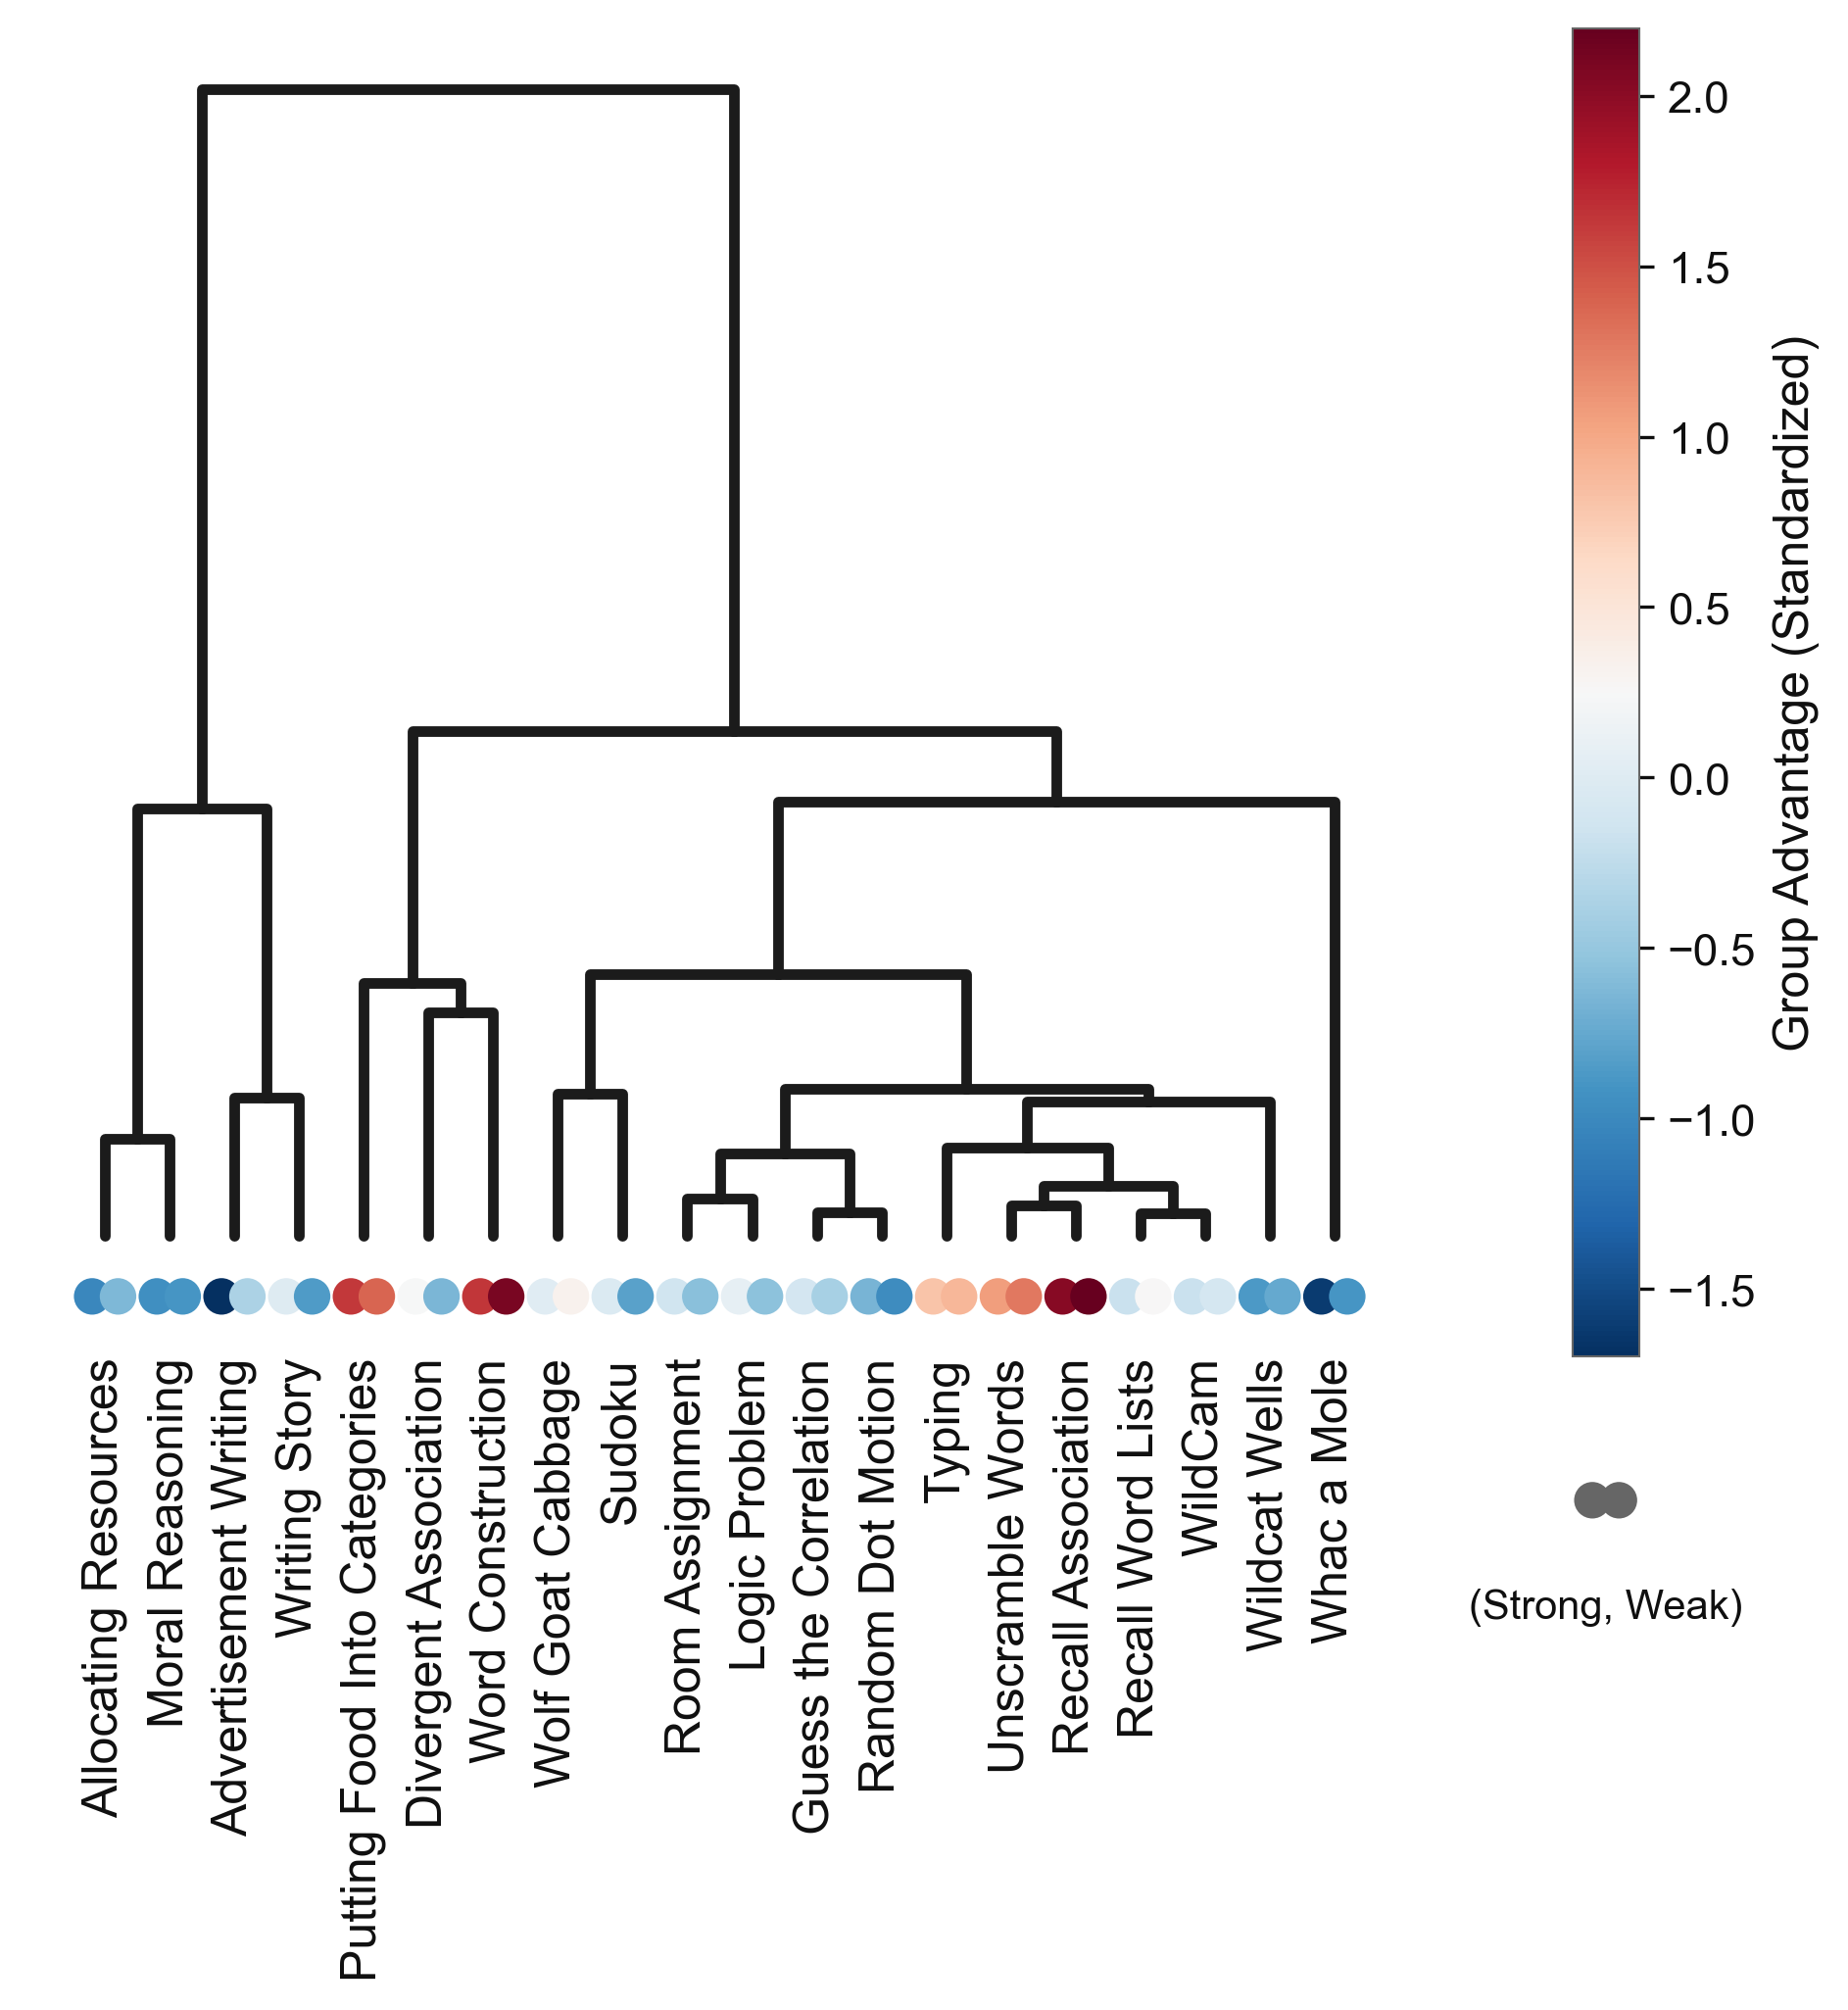

In [293]:
fig, ax = plot_task_dendrogram_with_synergy(
df=df_condition_level_data,
task_vars=task_vars,
strong_col="strong",
weak_col="weak",
method="average", # linkage method for clustering
metric="cosine", # distance for clustering
agg="median", # aggregation method for task dv's
vertical_compress=0.9,
label_rotation=90,
label_font_size=12,
label_pad_fraction=0.28,
orientation="top",        # change to "right" for horizontal layout
cmap_name="RdBu_r",      # or "viridis" for a similar high-contrast palette
line_width=2.6,
dpi=300,
)

fig.savefig("../outputs/task_dendrogram_for_group_adv.png", dpi=300, bbox_inches='tight')

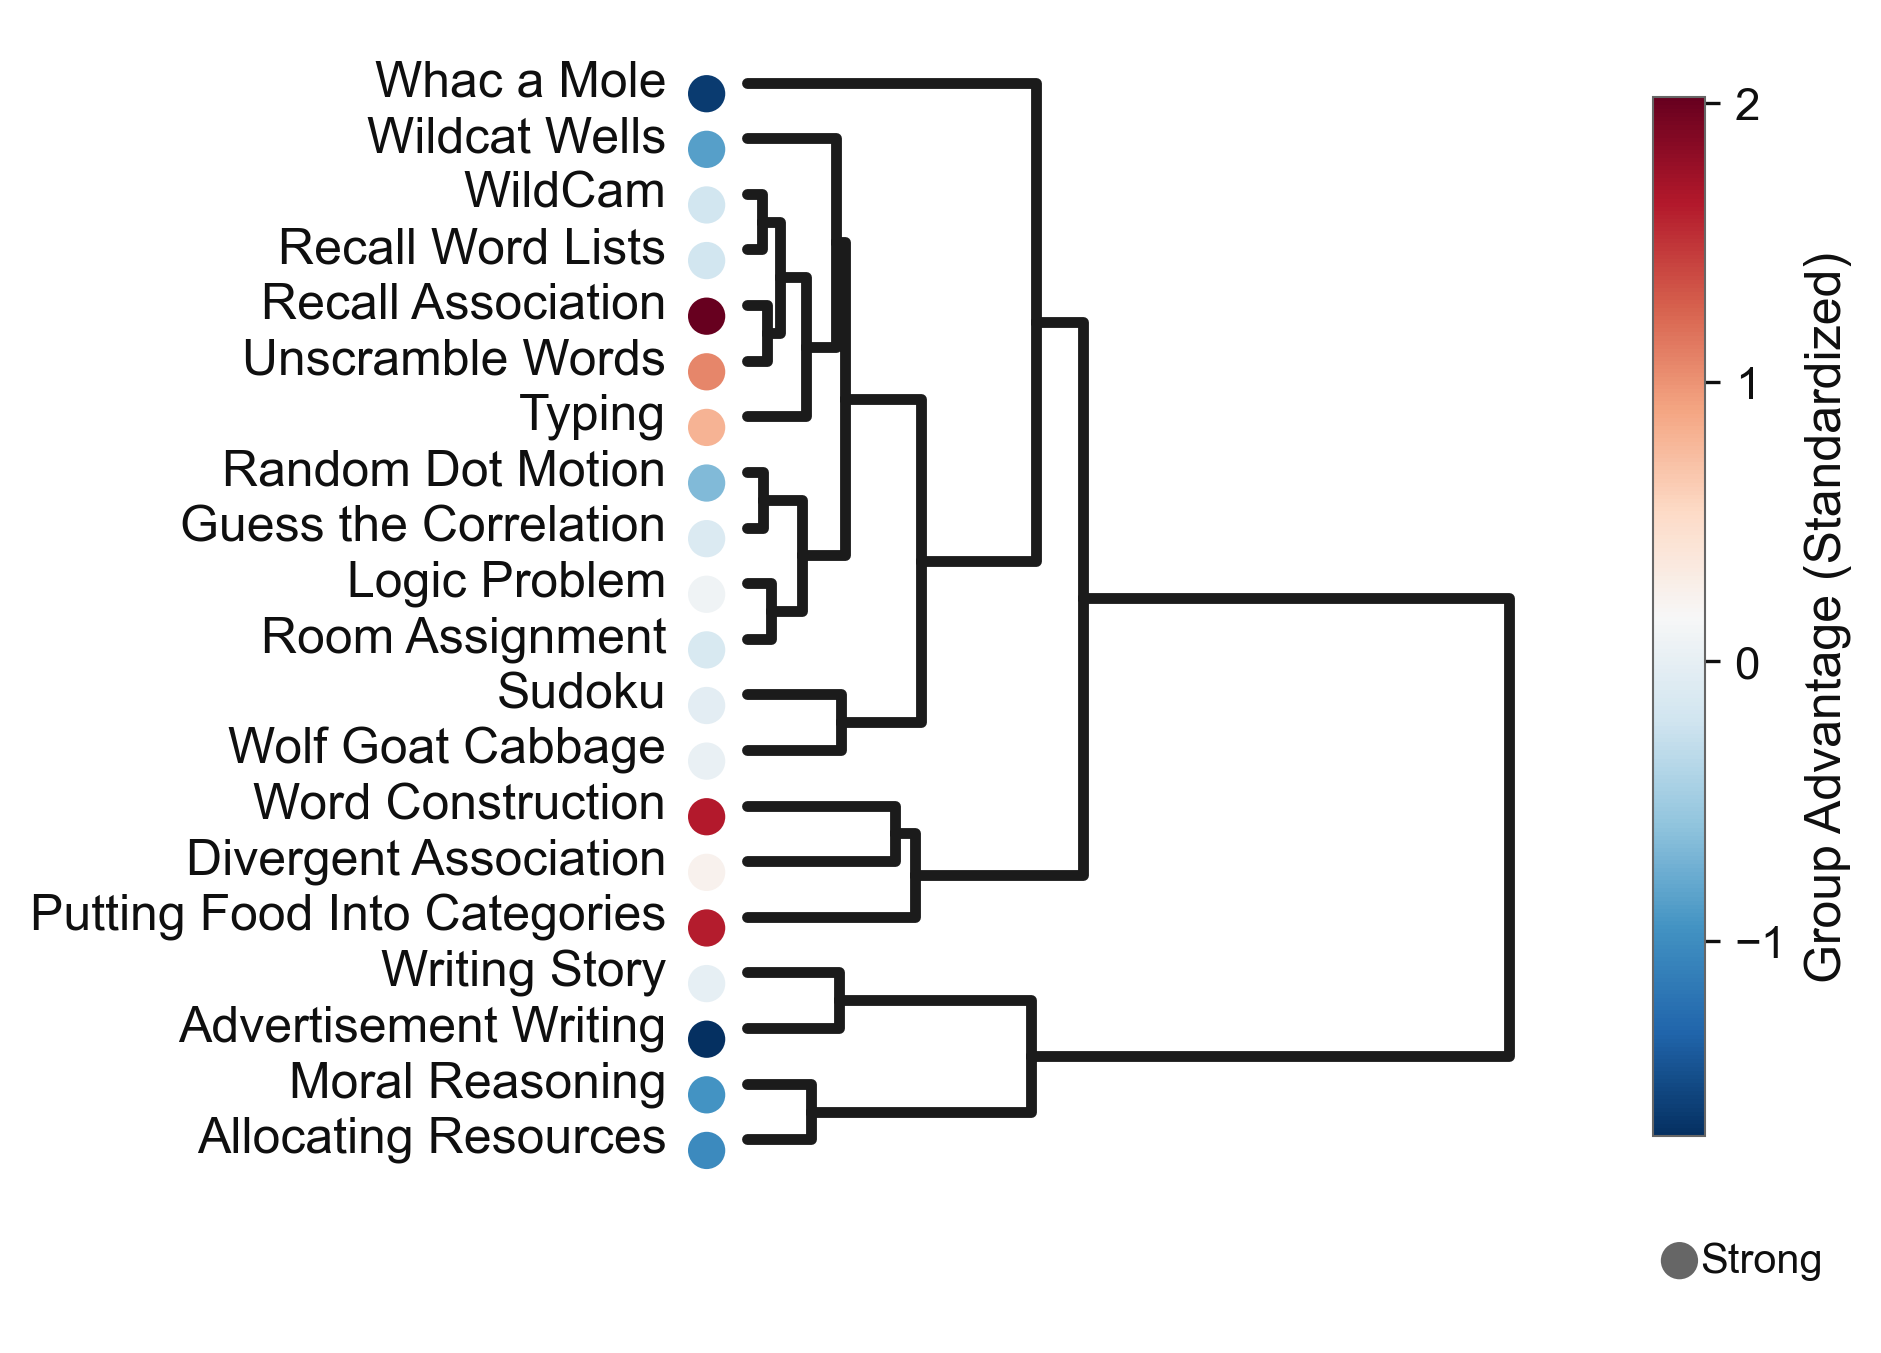

In [294]:
fig_horizontal, ax = plot_task_dendrogram_with_synergy(
df=df_condition_level_data,
task_vars=task_vars,
strong_col="strong",
weak_col="weak",
method="average", # linkage method for clustering
metric="cosine", # distance for clustering
agg="median", # aggregation method for task dv's
vertical_compress=0.9,
label_rotation=90,
label_font_size=12,
label_pad_fraction=0.28,
orientation="right",        # change to "right" for horizontal layout
cmap_name="RdBu_r",      # or "viridis" for a similar high-contrast palette
line_width=2.6,
dpi=300,
which="strong"
)